# Day 5 — Time Series Cross-Validation

Amaç:

- ARIMA modellerini tek bir test dönemi yerine birden fazla zaman döneminde test etmek
- Expanding window mantığını öğrenmek
- Modelleri ortalama MAE ve RMSE değerleriyle karşılaştırmak
- Daha güvenilir ARIMA parametreleri belirlemek

# Hatırlatma 

Önce Day 4’ü zihnimizde yerine oturtalım, sonra Day 5’e başlayalım.

Dün yaptığımız akış şuydu:

```text
157 haftalık ChatGPT verisi
        ↓
145 hafta TRAIN
12 hafta TEST
        ↓
Naive baseline
MAE  = 4.17
RMSE = 5.05
        ↓
ARIMA için durağanlık kontrolü
        ↓
Ham seri:
p-value = 0.7695 → durağan diyemedik
        ↓
1 kez differencing
        ↓
p-value ≈ 0 → durağan
        ↓
d = 1
        ↓
ACF + PACF
        ↓
ARIMA adayları
```

Sonra aynı 12 haftalık test döneminde birkaç modeli karşılaştırdık:

```text
Model            MAE     RMSE
ARIMA(1,1,1)     3.71    4.51   ← en iyi
ARIMA(0,1,2)     3.90    4.68
ARIMA(2,1,2)     4.06    4.87
ARIMA(2,1,0)     4.12    4.95
Naive            4.17    5.05
```

Yani şu anda **ARIMA(1,1,1) en iyi adayımız**, ama henüz “nihai model” demiyoruz.

Neden? Çünkü onu sadece **tek bir 12 haftalık dönemde** sınadık.

Mesela sınavımız şu oldu:

```text
2023 ---------------- Mayıs 2026 | Mayıs–Temmuz 2026
           TRAIN                 |      TEST
```

Belki ARIMA(1,1,1) özellikle bu dönemde iyi çalıştı. Daha önceki bir 12 haftalık dönemi tahmin etmeye çalışsaydı belki başka bir model daha iyi olacaktı.

İşte **Day 5’in ana konusu bu: time-series cross-validation.**

Normal cross-validation’ın amacı bir modeli bir kez değil, **birkaç farklı sınavda değerlendirmek**.

Ama zaman serisinde tarihler karıştırılamaz. Dolayısıyla şöyle yapacağız:

```text
1. sınav
TRAIN: █████████████
TEST:               ████

2. sınav
TRAIN: █████████████████
TEST:                   ████

3. sınav
TRAIN: █████████████████████
TEST:                       ████
```

Dikkat edersen train her seferinde büyüyor. Buna **expanding window** deniyor.

Mantığı:

> İlk sınavda belli bir tarihe kadar bildiklerimizi kullanıp sonraki dönemi tahmin et.

Sonra biraz daha zaman geçmiş gibi davran:

> Artık önceki test dönemini de biliyoruz; train’i büyüt ve sonraki dönemi tahmin et.

Bu gerçek hayata çok benziyor.

Örneğin:

```text
Ocak–Aralık → öğren
Ocaktan sonraki 4 hafta → tahmin et

sonra

Ocak–Ocak sonu → öğren
sonraki 4 hafta → tahmin et
```

Böylece model sadece **2026 yazında mı iyi**, yoksa farklı dönemlerde de gerçekten iyi mi göreceğiz.

Day 5’te hedefimiz:

```text
ARIMA adayları
      ↓
birkaç farklı zaman diliminde sınav
      ↓
her sınavda MAE / RMSE
      ↓
ortalama MAE / RMSE
      ↓
daha güvenilir model seçimi
```

Ve önemli olarak bugün doğrudan karmaşık döngü koduna atlamayacağız.

İlk adımda **`TimeSeriesSplit` nedir ve train/test parçalarını nasıl oluşturuyor** onu küçük bir örnekle göreceğiz. Sonra bizim gerçek verimize uygularız.


In [1]:
import pandas as pd

clean_data = pd.read_csv(
    "../data/processed/google_trends_ai_3y_clean.csv",
    index_col="date",
    parse_dates=["date"],
)

chatgpt = clean_data["chatgpt"]

In [5]:
len(chatgpt)

157

Day 5’e hoş geldin! Bu günün ana olayı **mühendislik yaklaşımını zaman serisine entegre etmek**.

Yazdığın plan çok temiz. Benden istediğin gibi, kodu bir kenara bırakıp bu adımların arkasındaki **mantığı, mimari kararları ve "Neden böyle yapıyoruz?"** sorularını adım adım inceleyelim.

---

## 1. Neden Tek Bir Test Seti Yetmiyor? (Day 4 vs. Day 5)

Day 4’te verinin son 12 haftasını test için kenara ayırdın ve modelini eğittin. Ancak zaman serilerinde tek bir test setiyle modeli değerlendirmek büyük bir **"şans faktörü"** barındırır.

* **Ya o son 12 hafta çok sakinse?** Model mükemmel görünür ama gerçekte zayıftır.
* **Ya o son 12 haftada olağanüstü bir gelişme yaşandıysa?** (Örn: ChatGPT'nin yeni bir versiyonu çıktı ve aramalar fırladı). Model başarısız görünür ama aslında genel olarak iyidir.

İşte **Cross-Validation (Çapraz Doğrulama)** tam olarak bu şans faktörünü ortadan kaldırır. Modeli tek bir sınava değil, **farklı zaman dilimlerindeki 4 farklı sınava** sokarak ortalama başarısını ölçersin.

---

## 2. Klasik Cross-Validation Neden Zaman Serisinde Çöker?

Normal makine öğrenmesinde (mesela ev fiyatı tahmininde) veriyi rastgele karıştırıp (shuffle) %80 Train, %20 Test yapabilirsin.

**Zaman serisinde bunu yapamazsın.** Çünkü zaman serisinin en büyük kuralı şudur: **Gelecek, geçmişi bilerek tahmin edilir; geçmiş, gelecekten öğrenilemez.**

Eğer veriyi rastgele karıştırırsan:

* Model 2024 Ekim verisini öğrenip 2024 Ağustos verisini tahmin etmeye çalışır.
* Bu duruma **Data Leakage (Veri Sızıntısı)** denir ve model kopyayla sınava girmiş gibi olur.

---

## 3. "Expanding Window" (Genişleyen Pencere) Mantığı

İşte bu yüzden `TimeSeriesSplit` kullanıyoruz. Bu yapı, zamanın doğal akışını bozmadan veri kümesini genişleterek ilerler:

```text
ZAMAN AKIŞI ─────────────────────────────────────────────────────────►

Fold 1:  [ Train: 1. Yıl ] ──► [ Test: 12 Hafta ]
Fold 2:  [ Train: 1. Yıl + 12 Hafta ] ──► [ Test: Sonraki 12 Hafta ]
Fold 3:  [ Train: 1. Yıl + 24 Hafta ] ──► [ Test: Sonraki 12 Hafta ]
Fold 4:  [ Train: 1. Yıl + 36 Hafta ] ──► [ Test: Sonraki 12 Hafta ]


```


Buradaki kritik detaylar:

1. **Train seti sürekli büyür (Expanding):** Tıpkı gerçek hayatta olduğu gibi! Zaman geçtikçe elinde daha fazla geçmiş veri birikir.
2. **Test seti hep gelecektedir:** Her sınavda model, *daha önce hiç görmediği* ve Train setinin hemen ardından gelen 12 haftayı tahmin etmeye çalışır.
3. **Test boyutu sabittir (`test_size=12`):** Her sınav eşit zorluktadır. Day 4 ile tutarlı olması için de 12 hafta seçilmiştir.

---

## Özetle Day 5'te Ne Başaracaksın?

Bu adımı tamamladığında elinde tek bir şanslı/şanssız test sonucu değil; **"Bu ARIMA modeli, yılın farklı dönemlerinde ortalama X kadar hata yapıyor"** diyebileceğin sağlam, mühendislik süzgecinden geçmiş ve güvenilir bir değerlendirme olacak.


In [ ]:
from sklearn.model_selection import TimeSeriesSplit

# model.selection “Modeli nasıl eğitip değerlendireceğiz?” ile ilgili araçların bulunduğu bölüm.

# TimeSeriesSplit ise özellikle zaman sırasını bozmadan train/test parçaları oluşturmamıza yardım ediyor.

In [4]:
tscv = TimeSeriesSplit(
    n_splits=4, # Modeli 4 farklı zaman döneminde sınayacağız.
    test_size=12, # Her sınavda 12 haftalık test dönemi olacak.
)

#Day 4’teki testimiz de 12 haftaydı; böylece karşılaştırmalar tutarlı olacak.

In [6]:
for fold, (train_index, test_index) in enumerate(
    tscv.split(chatgpt),
    start=1,
):
    print(
        f"Fold {fold}:",
        f"Train = {len(train_index)} hafta,",
        f"Test = {len(test_index)} hafta",
    )

Fold 1: Train = 109 hafta, Test = 12 hafta
Fold 2: Train = 121 hafta, Test = 12 hafta
Fold 3: Train = 133 hafta, Test = 12 hafta
Fold 4: Train = 145 hafta, Test = 12 hafta


Şimdilik bu kod sadece:

“Cross-validation verimizi nasıl bölecek?”

onu gösterecek. Henüz hiçbir model eğitmiyoruz.

Şimdi **expanding window** gerçekten gözle görünür oldu:

Fold 1 → 109 hafta öğreniyor → sonraki 12 haftayı test ediyor
Fold 2 → 121 hafta öğreniyor → sonraki 12 haftayı test ediyor
Fold 3 → 133 hafta öğreniyor → sonraki 12 haftayı test ediyor
Fold 4 → 145 hafta öğreniyor → son 12 haftayı test ediyor

Dikkat: her seferinde train’e 12 yeni hafta ekleniyor, çünkü önceki fold’un test dönemi artık bir sonraki fold’da “geçmiş bilgi” haline geliyor.

Yani kabaca:

Fold 1:
[---------109 train---------][12 test]

Fold 2:
[-------------121 train-------------][12 test]

Fold 3:
[-----------------133 train-----------------][12 test]

Fold 4:
[---------------------145 train---------------------][12 test]

Ve Fold 4, Day 4’te elle yaptığımız şu bölünmeyle aynı:

145 train + 12 test

Bu çok güzel, çünkü cross-validation Day 4’teki tek sınavımızı çöpe atmıyor; onu 4 sınavdan biri haline getiriyor.



Şimdi tarihlerini de görelim.

In [ ]:
for fold, (train_index, test_index) in enumerate(
    tscv.split(chatgpt),
    start=1,
):
    fold_train = chatgpt.iloc[train_index] # gerçek train verisini
    fold_test = chatgpt.iloc[test_index] # gerçek test verisini çıkarıyoruz.

    print(f"Fold {fold}")
    print(
        "Train:",
        fold_train.index[0],
        "->",
        fold_train.index[-1],
    )
    print(
        "Test:",
        fold_test.index[0],
        "->",
        fold_test.index[-1],
    )
    print()

Fold 1
Train: 2023-07-30 00:00:00 -> 2025-08-24 00:00:00
Test: 2025-08-31 00:00:00 -> 2025-11-16 00:00:00

Fold 2
Train: 2023-07-30 00:00:00 -> 2025-11-16 00:00:00
Test: 2025-11-23 00:00:00 -> 2026-02-08 00:00:00

Fold 3
Train: 2023-07-30 00:00:00 -> 2026-02-08 00:00:00
Test: 2026-02-15 00:00:00 -> 2026-05-03 00:00:00

Fold 4
Train: 2023-07-30 00:00:00 -> 2026-05-03 00:00:00
Test: 2026-05-10 00:00:00 -> 2026-07-26 00:00:00



In [9]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

In [10]:
#  sonuçları saklamak için boş listeler oluşturacağız:
cv_mae = []
cv_rmse = []

Burada yapçağımız şey Day 4’teki işlemin aynısı, sadece 4 kez tekrarlanıyor:

fold_train
→ ARIMA(1,1,1)
→ fit
→ 12 haftalık forecast
→ gerçek fold_test ile karşılaştır
→ MAE / RMSE

In [11]:
for fold, (train_index, test_index) in enumerate(
    tscv.split(chatgpt),
    start=1,
):
    fold_train = chatgpt.iloc[train_index]
    fold_test = chatgpt.iloc[test_index]

    model = ARIMA(
        fold_train,
        order=(1, 1, 1),
    )

    fitted_model = model.fit()

    prediction = fitted_model.forecast(
        steps=len(fold_test)
    )

    fold_mae = mean_absolute_error(
        fold_test,
        prediction,
    )

    fold_rmse = root_mean_squared_error(
        fold_test,
        prediction,
    )

    cv_mae.append(fold_mae)
    cv_rmse.append(fold_rmse)

    print(
        f"Fold {fold} - "
        f"MAE: {fold_mae:.2f}, "
        f"RMSE: {fold_rmse:.2f}"
    )

Fold 1 - MAE: 6.27, RMSE: 7.03
Fold 2 - MAE: 13.72, RMSE: 15.38
Fold 3 - MAE: 3.00, RMSE: 3.73
Fold 4 - MAE: 3.71, RMSE: 4.51


/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init

Evet, Fold 3 en düşük hataya sahip. Ama burada “Fold 3 daha iyi model” demiyoruz; model aynı **ARIMA(1,1,1)**. Değişen şey, modelin sınava girdiği **zaman dönemi**.

Fold 2’nin çok kötü çıkması bize aslında cross-validation’ın neden gerekli olduğunu gösteriyor.

Day 4’te sadece Fold 4’ü görmüştük:

```text
Fold 4
MAE = 3.71
RMSE = 4.51
```

Buna bakıp “ARIMA(1,1,1) gayet iyi” diyebilirdik.

Ama şimdi gördük:

```text
Fold 1 → MAE  6.27
Fold 2 → MAE 13.72  ← çok kötü
Fold 3 → MAE  3.00  ← çok iyi
Fold 4 → MAE  3.71
```

Yani modelin başarısı **hangi dönemi tahmin ettiğine göre ciddi biçimde değişiyor**.

Bunun birkaç mantıklı sebebi var.

İlk olarak Fold 1 ve özellikle Fold 2 döneminde gerçek ChatGPT ilgisi, modelin geçmişten öğrendiği davranıştan farklı hareket etmiş olabilir. ARIMA geçmişteki düzeni kullanıyor. Mesela geçmişte seri kabaca:

```text
70 → 71 → 72 → 71 → 73
```

gibi davranıyorsa model buna göre geleceği tahmin eder.

Ama test döneminde birden:

```text
73 → 80 → 90 → 95
```

gibi yeni bir hareket başlarsa model bunu önceden bilemez. İşte hata patlar.

İkinci önemli sebep: biz her fold’da **12 haftayı bir kerede tahmin ediyoruz**.

Fold 2’de model:

> “2025-11-16’ya kadar her şeyi biliyorsun. Şimdi bundan sonraki 12 haftayı hiç yeni bilgi almadan tahmin et.”

sınavına giriyor.

Yani model 1. test haftasının gerçek sonucunu gördükten sonra kendini güncellemiyor. 12 haftayı tamamen 2025-11-16’da bildikleriyle tahmin ediyor.

Bu önemli çünkü gerçek hayatta seri değişmeye başlarsa:

```text
1. hafta → beklenmedik hareket
2. hafta → yine farklı
3. hafta → yeni seviye
...
```

ARIMA hâlâ eski geçmişten yaptığı tahminlerle devam ediyor.

Üçüncü sebep ise **rejim değişimi** dediğimiz şey olabilir. Bunu basitçe:

> “Serinin davranış biçiminin bir dönemden diğerine değişmesi”

olarak düşün.

Örneğin ChatGPT ilgisi ilk dönemlerde hızlı büyüyebilir, başka bir dönemde büyük sıçramalar yaşayabilir, daha sonraki dönemde 70 civarında dengelenebilir.

ARIMA(1,1,1) bir dönemdeki düzeni çok iyi yakalarken başka bir dönemde zorlanabilir.

Fold 3 ve Fold 4’ün iyi çıkmasının olası açıklaması da bu: bu dönemlerde seri, modelin train verisinden öğrendiği yapıya daha çok benziyor olabilir.

Ama bunu tahmin ederek bırakmayalım. **Bir sonraki adımda kesin olarak göreceğiz.**

Fold 1–4 için:

```text
gerçek değer
vs.
ARIMA tahmini
```

grafiğini çıkaracağız.

Özellikle Fold 2’de gerçek seri ne yapmış, ARIMA ne tahmin etmiş göreceğiz. O zaman `MAE = 13.72`nin neden oluştuğu gözümüzün önünde olacak.

Bir de bundan sonra asıl önemli sayı tek tek foldların değil, **4 fold’un ortalama MAE ve RMSE’si** olacak. Cross-validation’ın amacı zaten modelin yalnız iyi olduğu dönemi değil, kötü olduğu dönemleri de hesaba katmak.


Şimdi önce 4 fold’un ortalama performansını bulalım; çünkü cross-validation’ın asıl amacı tek bir fold’a değil, genel performansa bakmak.

In [15]:
average_cv_mae= sum(cv_mae)/ len(cv_mae)
average_cv_rmse=sum(cv_rmse)/(len(cv_rmse))





In [16]:
print("Average CV MAE:", average_cv_mae)
print("Average CV RMSE:", average_cv_rmse)

Average CV MAE: 6.676767114519856
Average CV RMSE: 7.6631285450011815


Sonra Fold 2 neden bu kadar kötü, onu gerçekten görmek için sadece Fold 2’yi tekrar çıkaralım:

In [17]:
splits = list(tscv.split(chatgpt))

train_index, test_index = splits[1] # splits[1] = Fold 2

fold2_train = chatgpt.iloc[train_index]
fold2_test = chatgpt.iloc[test_index]

* splits[0] → Fold 1
* splits[1] → Fold 2
* splits[2] → Fold 3
* splits[3] → Fold 4

In [18]:
fold2_model = ARIMA( # fold 2 için modeli yeniden kurduk
    fold2_train,
    order=(1, 1, 1),
)

fold2_fit = fold2_model.fit()

fold2_prediction = fold2_fit.forecast(
    steps=len(fold2_test)
)

/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)


In [19]:
fold2_comparison = pd.DataFrame( # gerçek ve tahmini yan yana koyalım
    {
        "actual": fold2_test,
        "prediction": fold2_prediction,
    }
)

fold2_comparison

,actual,prediction
2025-11-23,75,84.141425
2025-11-30,75,84.195733
2025-12-07,76,84.216587
2025-12-14,75,84.224596
2025-12-21,57,84.227671
2025-12-28,54,84.228852
2026-01-04,71,84.229305
2026-01-11,73,84.229479
2026-01-18,70,84.229546
2026-01-25,73,84.229572


Evet, bence bunu **şimdi yapmamız çok iyi olur**. Şu ana kadar sayılara bakıyoruz ama 4 fold boyunca modelin nerede iyi, nerede koptuğunu tek grafikte görmek çok daha öğretici.

Amacımız şu:

```text
2025-08-31 -------------------------------- 2026-07-26

Gerçek değerler    ─────────
ARIMA tahminleri   ─────────

Fold 1 | Fold 2 | Fold 3 | Fold 4
```

Yani toplam **4 × 12 = 48 haftalık** test dönemini tek zaman çizgisinde göreceğiz.

Önce bütün fold sonuçlarını tek DataFrame'de toplayalım:

```python
all_fold_results = []

for fold, (train_index, test_index) in enumerate(
    tscv.split(chatgpt),
    start=1,
):
    fold_train = chatgpt.iloc[train_index]
    fold_test = chatgpt.iloc[test_index]

    model = ARIMA(
        fold_train,
        order=(1, 1, 1),
    )

    fitted_model = model.fit()

    prediction = fitted_model.forecast(
        steps=len(fold_test)
    )

    fold_result = pd.DataFrame(
        {
            "actual": fold_test,
            "prediction": prediction,
        }
    )

    fold_result["fold"] = fold

    all_fold_results.append(fold_result)
```

Burada yeni olan esas şey:

```python
all_fold_results = []
```

Her fold'un 12 haftalık sonucunu burada biriktiriyoruz.

Sonra:

```python
all_cv_results = pd.concat(
    all_fold_results
)

all_cv_results
```

`pd.concat()` burada 4 ayrı küçük DataFrame'i **alt alta birleştiriyor**.

Sonuç şöyle bir yapı olacak:

```text
date          actual   prediction   fold
...
2025-08-31      ...       ...         1
...
2025-11-23      75       84.14        2
...
2026-02-15      ...       ...         3
...
2026-05-10      72       ...          4
```

Şimdi asıl istediğin bütüncül grafik:

```python
plt.figure(figsize=(14, 6))

plt.plot(
    all_cv_results.index,
    all_cv_results["actual"],
    label="Actual",
)

plt.plot(
    all_cv_results.index,
    all_cv_results["prediction"],
    label="ARIMA(1,1,1) Prediction",
)

plt.title(
    "ARIMA(1,1,1) Cross-Validation: Actual vs Prediction"
)
plt.xlabel("Date")
plt.ylabel("Google Trends Interest")
plt.legend()
plt.show()
```

Bu grafik bize çok daha önemli sorular sorduracak:

> Model gerçek serinin yönünü takip edebiliyor mu?

> Model yükseliş/düşüşleri yakalıyor mu, yoksa belli bir değerde takılı mı kalıyor?

> Fold 2'deki büyük hata tek bir haftadan mı geliyor, yoksa bütün 12 hafta boyunca model yanlış seviyede mi?

> Fold 3 neden bu kadar başarılı olmuş?

Bir de **sadece grafiğe değil, farklara da bakalım**. Şunu ekleyebilirsin:

```python
all_cv_results["error"] = (
    all_cv_results["actual"]
    - all_cv_results["prediction"]
)

all_cv_results["absolute_error"] = (
    all_cv_results["error"].abs()
)
```

Burada:

```text
error > 0
```

ise gerçek değer tahminden yüksek; yani model **düşük tahmin etmiş**.

```text
error < 0
```

ise model gerçek değerden yüksek tahmin etmiş; yani model **fazla tahmin etmiş**.

Mesela Fold 2'de:

```text
actual = 54
prediction = 84.23

error = 54 - 84.23
      = -30.23
```

Yani model gerçek ilgiyi **yaklaşık 30 puan fazla tahmin etmiş**.

Önce `all_cv_results` tablosunu ve tek grafiği çıkar. **Grafiği bana gönder.** Sonra bu kez sadece “MAE kaç?” demeyeceğiz; grafiği dönem dönem okuyup modelin davranışını gerçekten yorumlayacağız.


In [21]:
all_fold_results = []# Önce bütün fold sonuçlarını tek DataFrame'de toplayalım:

for fold, (train_index, test_index) in enumerate(
    tscv.split(chatgpt),
    start=1,
):
    fold_train = chatgpt.iloc[train_index]
    fold_test = chatgpt.iloc[test_index]

    model = ARIMA(
        fold_train,
        order=(1, 1, 1),
    )

    fitted_model = model.fit()

    prediction = fitted_model.forecast(
        steps=len(fold_test)
    )

    fold_result = pd.DataFrame(
        {
            "actual": fold_test,
            "prediction": prediction,
        }
    )

    fold_result["fold"] = fold

    all_fold_results.append(fold_result)

/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init

In [22]:
all_cv_results = pd.concat( # 4 ayrı küçük DataFrame'i alt alta birleştiriyor.
    all_fold_results
)

all_cv_results

,actual,prediction,fold
2025-08-31,79,78.119961,1
2025-09-07,85,77.744489,1
2025-09-14,91,77.584293,1
2025-09-21,79,77.515944,1
2025-09-28,82,77.486783,1
2025-10-05,85,77.474342,1
2025-10-12,85,77.469033,1
2025-10-19,83,77.466769,1
2025-10-26,82,77.465802,1
2025-11-02,85,77.465390,1


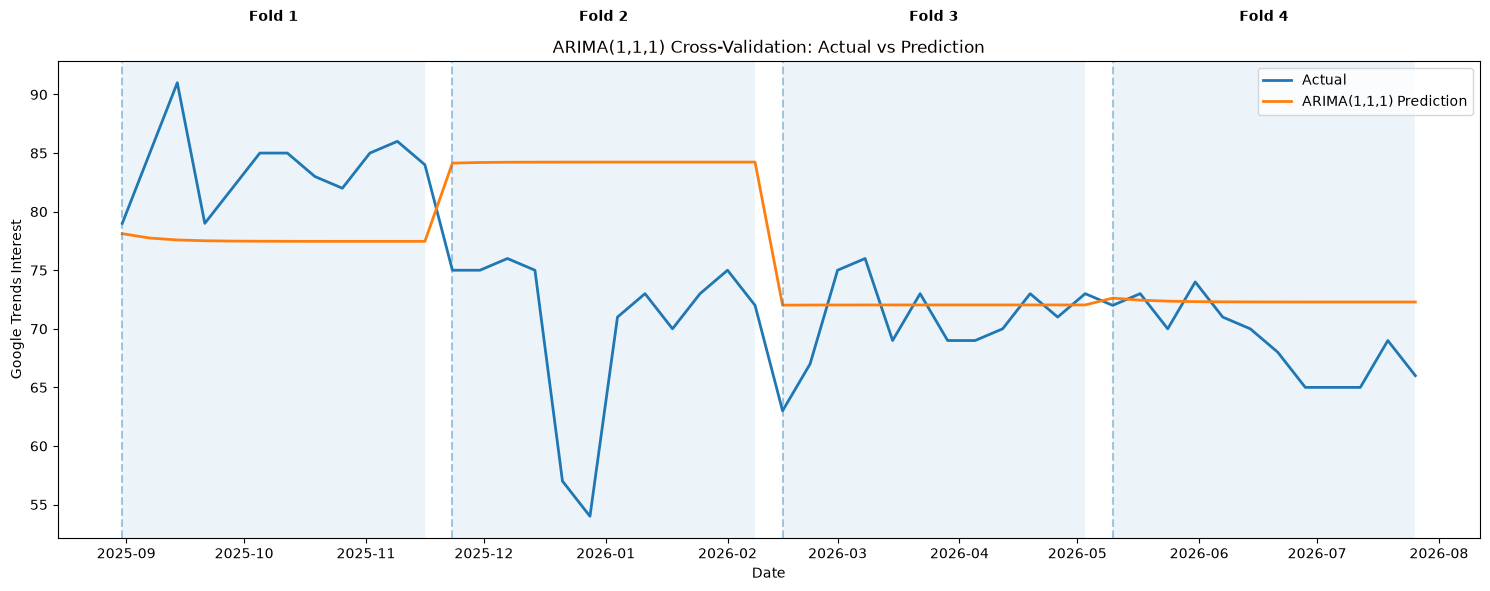

In [25]:
import matplotlib.pyplot as plt
import pandas as pd

all_cv_results = pd.concat(all_fold_results)
all_cv_results = all_cv_results.sort_index()

all_cv_results["error"] = (
    all_cv_results["actual"] - all_cv_results["prediction"]
)

all_cv_results["absolute_error"] = all_cv_results["error"].abs()

plt.figure(figsize=(15, 6))

# Gerçek ve tahmin çizgileri
plt.plot(
    all_cv_results.index,
    all_cv_results["actual"],
    label="Actual",
    linewidth=2,
)

plt.plot(
    all_cv_results.index,
    all_cv_results["prediction"],
    label="ARIMA(1,1,1) Prediction",
    linewidth=2,
)

# Fold bölgelerini ekle
y_top = all_cv_results[["actual", "prediction"]].max().max() + 5

for i, fold in enumerate(sorted(all_cv_results["fold"].unique())):
    fold_data = all_cv_results[
        all_cv_results["fold"] == fold
    ]

    start_date = fold_data.index.min()
    end_date = fold_data.index.max()

    # Bölgeyi hafif gölgele
    plt.axvspan(
        start_date,
        end_date,
        alpha=0.08,
    )

    # Fold yazısını ortaya koy
    middle_date = start_date + (end_date - start_date) / 2

    plt.text(
        middle_date,
        y_top,
        f"Fold {fold}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )

    # İstersen sınır çizgisi de koy
    plt.axvline(
        start_date,
        linestyle="--",
        alpha=0.4,
    )

plt.title("ARIMA(1,1,1) Cross-Validation: Actual vs Prediction")
plt.xlabel("Date")
plt.ylabel("Google Trends Interest")
plt.legend()
plt.tight_layout()
plt.show()

Evet, bu grafik tam istediğimiz şeyi gösteriyor. Şimdi modelin davranışını gerçekten görebiliyoruz.

En dikkat çekici şey şu: **turuncu ARIMA tahmini her fold içinde neredeyse düz bir çizgiye dönüşüyor.** Yani model 12 haftalık tahmini bir kerede yaptığında, ilk birkaç adımdan sonra belli bir seviyeye oturuyor ve yeni gelişmeleri göremediği için orada kalıyor.

Fold’ları tek tek okuyalım:

* **Fold 1:** Gerçek değerler çoğunlukla `79–91` civarında, model ise yaklaşık `77–78` tahmin ediyor. Yani model genel olarak **düşük tahmin etmiş**. Bu yüzden MAE `6.27`.
* **Fold 2:** En büyük problem burada. Model geçmişten “yaklaşık 84 seviyesi devam edecek” diye öğrenmiş. Ama gerçek seri önce `75` civarında, sonra bir anda `57 → 54` seviyesine düşmüş. Model hâlâ `84` demeye devam ediyor. Bu yüzden MAE `13.72`, RMSE `15.38` gibi çok kötü çıkıyor.
* **Fold 3:** Model yaklaşık `72` tahmin ediyor. Gerçek seri `63–76` arasında dalgalansa da çoğu değer 72 çevresinde. Bu yüzden model şanslı biçimde gerçek seviyeye oldukça yakın kalıyor ve **en iyi fold** oluyor: MAE `3.00`.
* **Fold 4:** Model yine yaklaşık `72` civarında. Gerçek seri ilk başta 72 civarında ama sonra `65–69` seviyelerine düşüyor. Bu nedenle model sonlara doğru biraz yüksek tahmin ediyor. MAE `3.71`.

Grafikten bence asıl önemli çıkarım şu:

> **ARIMA(1,1,1) ani seviye değişikliklerini yakalamakta zorlanıyor.**

Özellikle Fold 2 bunun çok açık örneği. Model test dönemine girerken yalnızca geçmişi biliyor. Test sırasında `75 → 57 → 54` gibi yeni bir hareket olduğunda kendisini güncellemiyoruz; 12 haftayı baştan tahmin etmiş durumda.

Bir başka çok önemli şey de fold geçişlerinde turuncu çizginin sıçraması:

```text
Fold 1 ≈ 77
Fold 2 ≈ 84
Fold 3 ≈ 72
Fold 4 ≈ 72
```

Çünkü her fold’da model **farklı miktarda geçmiş veriyle yeniden eğitiliyor**. Yani modelin “geleceğin normal seviyesi ne?” görüşü de dönemden döneme değişiyor.

Bu yüzden artık şu yorumu güvenle yapabiliriz:

> ARIMA(1,1,1), bazı dönemlerde oldukça iyi tahmin üretirken bazı dönemlerde özellikle ani trend/seviye değişimlerinde ciddi şekilde yanılmaktadır. Tek test döneminde elde edilen iyi sonuç, modelin genel performansını temsil etmemektedir.

Şimdi en mantıklı sonraki adım: **Naive, ARIMA(2,1,0), ARIMA(0,1,2), ARIMA(2,1,2) ve ARIMA(1,1,1)’in hepsini aynı 4 fold cross-validation’dan geçirmek.** Böylece “Fold 2’de sadece (1,1,1) mi kötü, yoksa bütün modeller mi zorlanıyor?” sorusunu cevaplayacağız.


Şimdi aynı 4 fold’u her ARIMA modeli için tekrar tekrar elle yazmamak için küçük bir fonksiyon oluşturacağız.

Fonksiyonun görevi:

ARIMA order ver
ör: (1, 1, 1)
       ↓
4 fold'u sırayla çalıştır
       ↓
her fold'da modeli eğit
       ↓
12 hafta tahmin et
       ↓
MAE + RMSE hesapla
       ↓
4 fold'un ortalamasını döndür

In [27]:
def evaluate_arima_cv(series, tscv, order):
    fold_maes = []
    fold_rmses = []

    for train_index, test_index in tscv.split(series):
        fold_train = series.iloc[train_index]
        fold_test = series.iloc[test_index]

        model = ARIMA(
            fold_train,
            order=order,
        )

        fitted_model = model.fit()

        prediction = fitted_model.forecast(
            steps=len(fold_test)
        )

        mae = mean_absolute_error(
            fold_test,
            prediction,
        )

        rmse = root_mean_squared_error(
            fold_test,
            prediction,
        )

        fold_maes.append(mae)
        fold_rmses.append(rmse)

    average_mae = sum(fold_maes) / len(fold_maes)
    average_rmse = sum(fold_rmses) / len(fold_rmses)

    return average_mae, average_rmse

Önce sadece bildiğimiz (1,1,1) ile test edelim:

In [28]:
cv_111_mae, cv_111_rmse = evaluate_arima_cv(
    chatgpt,
    tscv,
    (1, 1, 1),
)

print("ARIMA(1,1,1) CV MAE:", cv_111_mae)
print("ARIMA(1,1,1) CV RMSE:", cv_111_rmse)

ARIMA(1,1,1) CV MAE: 6.676767114519856
ARIMA(1,1,1) CV RMSE: 7.6631285450011815


/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init

In [29]:
arima_orders = [
    (2, 1, 0),
    (0, 1, 2),
    (2, 1, 2),
    (1, 1, 1),
]

In [30]:
cv_results = []

for order in arima_orders:
    average_mae, average_rmse = evaluate_arima_cv(
        chatgpt,
        tscv,
        order,
    )

    cv_results.append(
        {
            "model": f"ARIMA{order}",
            "MAE": average_mae,
            "RMSE": average_rmse,
        }
    )

/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init

Burada yaptığımız şey:

(2,1,0) → 4 fold → ortalama MAE/RMSE
(0,1,2) → 4 fold → ortalama MAE/RMSE
(2,1,2) → 4 fold → ortalama MAE/RMSE
(1,1,1) → 4 fold → ortalama MAE/RMSE

Şimdi Naive baseline’ı da aynı 4 sınava sokmalıyız. Yoksa ARIMA’larla karşılaştırma adil olmaz.

In [31]:
naive_maes = []
naive_rmses = []

for train_index, test_index in tscv.split(chatgpt):
    fold_train = chatgpt.iloc[train_index]
    fold_test = chatgpt.iloc[test_index]

    last_value = fold_train.iloc[-1]

    naive_prediction = pd.Series(
        last_value,
        index=fold_test.index,
    )

    naive_maes.append(
        mean_absolute_error(
            fold_test,
            naive_prediction,
        )
    )

    naive_rmses.append(
        root_mean_squared_error(
            fold_test,
            naive_prediction,
        )
    )

cv_results.append(
    {
        "model": "Naive",
        "MAE": sum(naive_maes) / len(naive_maes),
        "RMSE": sum(naive_rmses) / len(naive_rmses),
    }
)

In [32]:
cv_results_df = pd.DataFrame(cv_results) # tablo

cv_results_df = cv_results_df.sort_values(
    "MAE"
).reset_index(drop=True)

cv_results_df

,model,MAE,RMSE
0,Naive,6.375000,7.425337
1,"ARIMA(1, 1, 1)",6.676767,7.663129
2,"ARIMA(0, 1, 2)",6.771778,7.735467
3,"ARIMA(2, 1, 0)",6.802622,7.800426
4,"ARIMA(2, 1, 2)",6.854089,7.839816


Bu sonuç çok önemli çünkü **Day 4’teki sonucumuzu değiştiriyor.**

Day 4’te sadece son 12 haftaya baktığımızda:

```text
ARIMA(1,1,1) → MAE 3.71
Naive        → MAE 4.17
```

demiştik ve ARIMA daha iyi görünüyordu.

Ama şimdi 4 farklı dönemde sınayınca:

```text
Model           Ortalama MAE    Ortalama RMSE
Naive              6.38             7.43   ← en iyi
ARIMA(1,1,1)       6.68             7.66
ARIMA(0,1,2)       6.77             7.74
ARIMA(2,1,0)       6.80             7.80
ARIMA(2,1,2)       6.85             7.84
```

Yani **cross-validation'a göre şu ana kadar en iyi model Naive baseline.**

Bu kötü bir sonuç değil. Tam tersine önemli bir veri bilimi sonucu:

> Denediğimiz ARIMA modelleri, farklı zaman dönemlerinde değerlendirildiğinde “son bilinen değeri sabit tut” kadar basit bir yöntemi bile genel olarak geçemiyor.

Bu bize iki şey söylüyor.

Birincisi, **ARIMA(1,1,1)’in Day 4’te iyi görünmesi büyük ölçüde son test dönemine özgüymüş.** Fold 3 ve Fold 4’te iyi ama Fold 1 ve özellikle Fold 2’de çok kötüleşiyor.

İkincisi, bu ChatGPT Trends serisinde ani seviye değişiklikleri ve dış olay kaynaklı sıçramalar var. Basit ARIMA modelleri 12 haftayı tek seferde tahmin ederken bu değişimleri yakalamakta zorlanıyor.

Şu anda kesinlikle:

> “En iyi model ARIMA(1,1,1)”

dememeliyiz.

Şimdiki doğru ifade:

> **Test edilen modeller arasında cross-validation ortalamasında Naive baseline en düşük MAE ve RMSE değerlerini verdi.**

Ama burada bırakmayacağız. Şimdi bence çok önemli bir şey yapalım: **her modelin Fold 1, Fold 2, Fold 3 ve Fold 4’te ayrı ayrı kaç hata yaptığını tek tabloda görelim.**

Çünkü şu anda yalnızca ortalamayı görüyoruz. Mesela şu soruyu cevaplamak istiyoruz:

> Fold 2’de bütün ARIMA modelleri mi çöküyor, yoksa bazıları o dönemi daha iyi yakalıyor mu?

Bunun için `evaluate_arima_cv()` fonksiyonumuzu biraz geliştirip sadece ortalama değil, **her fold sonucunu da saklayacağız**. Ondan sonra hangi modelin hangi dönemde güçlü/zayıf olduğunu çok daha bütüncül yorumlayabiliriz.


In [33]:
detailed_results = []

for order in arima_orders:
    for fold, (train_index, test_index) in enumerate(
        tscv.split(chatgpt),
        start=1,
    ):
        fold_train = chatgpt.iloc[train_index]
        fold_test = chatgpt.iloc[test_index]

        model = ARIMA(
            fold_train,
            order=order,
        )

        fitted_model = model.fit()

        prediction = fitted_model.forecast(
            steps=len(fold_test)
        )

        mae = mean_absolute_error(
            fold_test,
            prediction,
        )

        rmse = root_mean_squared_error(
            fold_test,
            prediction,
        )

        detailed_results.append(
            {
                "model": f"ARIMA{order}",
                "fold": fold,
                "MAE": mae,
                "RMSE": rmse,
            }
        )

/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init

In [34]:
for fold, (train_index, test_index) in enumerate(
    tscv.split(chatgpt),
    start=1,
):
    fold_train = chatgpt.iloc[train_index]
    fold_test = chatgpt.iloc[test_index]

    last_value = fold_train.iloc[-1]

    prediction = pd.Series(
        last_value,
        index=fold_test.index,
    )

    mae = mean_absolute_error(
        fold_test,
        prediction,
    )

    rmse = root_mean_squared_error(
        fold_test,
        prediction,
    )

    detailed_results.append(
        {
            "model": "Naive",
            "fold": fold,
            "MAE": mae,
            "RMSE": rmse,
        }
    )

In [35]:
detailed_results_df = pd.DataFrame(
    detailed_results
)

detailed_results_df

,model,fold,MAE,RMSE
0,"ARIMA(2, 1, 0)",1,6.227925,6.988577
1,"ARIMA(2, 1, 0)",2,13.860247,15.513012
2,"ARIMA(2, 1, 0)",3,3.004989,3.751885
3,"ARIMA(2, 1, 0)",4,4.117326,4.948232
4,"ARIMA(0, 1, 2)",1,6.533694,7.273685
5,"ARIMA(0, 1, 2)",2,13.695885,15.368785
6,"ARIMA(0, 1, 2)",3,2.959496,3.622118
7,"ARIMA(0, 1, 2)",4,3.898039,4.677279
8,"ARIMA(2, 1, 2)",1,6.496172,7.217086
9,"ARIMA(2, 1, 2)",2,13.844900,15.499134


In [36]:
mae_by_fold = detailed_results_df.pivot(
    index="model",
    columns="fold",
    values="MAE",
)

mae_by_fold

fold,1,2,3,4
model,,,,
"ARIMA(0, 1, 2)",6.533694,13.695885,2.959496,3.898039
"ARIMA(1, 1, 1)",6.273070,13.717661,3.004469,3.711868
"ARIMA(2, 1, 0)",6.227925,13.860247,3.004989,4.117326
"ARIMA(2, 1, 2)",6.496172,13.844900,3.020002,4.055282
Naive,4.833333,13.500000,3.000000,4.166667


Buradaki yeni şey .pivot().

Şu uzun yapıdan:

model          fold    MAE
ARIMA(1,1,1)   1       6.27
ARIMA(1,1,1)   2      13.72
...

şuna çeviriyor:

                    Fold 1   Fold 2   Fold 3   Fold 4
ARIMA(1,1,1)         6.27    13.72     3.00     3.71
ARIMA(0,1,2)          ?        ?         ?        ?
Naive                 ?        ?         ?        ?

Şimdi tablo çok şey söylüyor. En önemli sonuç: **Fold 2 yalnızca ARIMA(1,1,1) için kötü değil; bütün modeller için kötü.** Yani sorun belli bir ARIMA ayarından çok, o dönemin tahmin edilmesinin zor olması.

Fold 1’de en iyi model **Naive: 4.83**. Bütün ARIMA’lar yaklaşık `6.2–6.5` civarında. Yani o dönemde “son değeri devam ettir” yaklaşımı ARIMA’dan daha iyi.

Fold 2’de:

```text
Naive           13.50
ARIMA(0,1,2)    13.70
ARIMA(1,1,1)    13.72
ARIMA(2,1,2)    13.84
ARIMA(2,1,0)    13.86
```

Hepsi çöküyor. Bunun grafikte nedenini gördük: gerçek seri `75` civarından bir anda `57–54` seviyelerine düşüyor. Modeller ise test başladığında bildikleri yüksek seviyenin devam edeceğini düşünüyor.

Üstelik bu 12 haftayı **tek seferde** tahmin ediyoruz. Yani model `57` gerçekleştiğinde “aa seri düştü, kendimi güncelleyeyim” demiyor. O gerçek değeri görmeden bütün 12 haftayı önceden tahmin etmiş durumda.

Fold 3 çok ilginç:

```text
ARIMA(0,1,2)    2.959
Naive           3.000
ARIMA(1,1,1)    3.004
```

Burada aslında modeller arasında neredeyse fark yok. Üçü de yaklaşık `3` hata yapıyor. Dolayısıyla “ARIMA Fold 3’te inanılmaz üstün” demek doğru olmaz.

Fold 4’te ise ARIMA gerçekten biraz avantaj sağlıyor:

```text
ARIMA(1,1,1)    3.71   ← en iyi
ARIMA(0,1,2)    3.90
ARIMA(2,1,2)    4.06
ARIMA(2,1,0)    4.12
Naive           4.17
```

Yani genel hikâye:

```text
Fold 1 → Naive açıkça daha iyi
Fold 2 → herkes kötü, Naive yine biraz daha iyi
Fold 3 → hepsi neredeyse aynı
Fold 4 → ARIMA(1,1,1) biraz daha iyi
```

Bu yüzden 4 fold ortalamasında Naive’ın kazanması artık çok mantıklı. ARIMA son dönemlerde biraz avantaj sağlıyor ama ilk iki dönemdeki kötü performansı bunu siliyor.

Bir de burada önemli bir tasarım noktasını fark ettik: projemizin asıl tahmin hedefi yaklaşık **30 gün**. Biz şu anda her fold’da **12 hafta ≈ 3 ay** ileri tahmin yaptırıyoruz. Bu, modeli değerlendirmek için yararlı ama gerçek hedefimizden daha uzun bir horizon. Dolayısıyla sıradaki mantıklı deney, cross-validation’ı **4 haftalık test horizonuyla** da yapmak. Böylece şu soruyu cevaplayacağız:

> “30 günlük gerçek proje hedefinde ARIMA hâlâ Naive’dan kötü mü?”

Bence Day 5’in bir sonraki adımı bu olmalı. Aynı sistemi koruyacağız ama `test_size=12` yerine yaklaşık 30 günü temsil eden **`test_size=4`** kullanacağız. Sonuçlar ciddi biçimde değişebilir.


# 4 Haftalık Tahmin Ettirme Denemesi

In [37]:
tscv_4w = TimeSeriesSplit(
    n_splits=12,
    test_size=4,
)

In [38]:
for fold, (train_index, test_index) in enumerate(
    tscv_4w.split(chatgpt),
    start=1,
):
    print(
        f"Fold {fold}: "
        f"Train = {len(train_index)}, "
        f"Test = {len(test_index)}"
    )

Fold 1: Train = 109, Test = 4
Fold 2: Train = 113, Test = 4
Fold 3: Train = 117, Test = 4
Fold 4: Train = 121, Test = 4
Fold 5: Train = 125, Test = 4
Fold 6: Train = 129, Test = 4
Fold 7: Train = 133, Test = 4
Fold 8: Train = 137, Test = 4
Fold 9: Train = 141, Test = 4
Fold 10: Train = 145, Test = 4
Fold 11: Train = 149, Test = 4
Fold 12: Train = 153, Test = 4


In [ ]:
# Sonra mevcut fonksiyonumuzu değiştirmeden kullanabiliyoruz:
 cv_4w_results = []

for order in arima_orders:
    average_mae, average_rmse = evaluate_arima_cv(
        chatgpt,
        tscv_4w,
        order,
    )

    cv_4w_results.append(
        {
            "model": f"ARIMA{order}",
            "MAE": average_mae,
            "RMSE": average_rmse,
        }
    )

/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init

In [40]:
#Naive baseline’ı da aynı 12 fold × 4 hafta sınavına sokalım:

naive_4w_maes = []
naive_4w_rmses = []

for train_index, test_index in tscv_4w.split(chatgpt):
    fold_train = chatgpt.iloc[train_index]
    fold_test = chatgpt.iloc[test_index]

    last_value = fold_train.iloc[-1]

    naive_prediction = pd.Series(
        last_value,
        index=fold_test.index,
    )

    naive_4w_maes.append(
        mean_absolute_error(
            fold_test,
            naive_prediction,
        )
    )

    naive_4w_rmses.append(
        root_mean_squared_error(
            fold_test,
            naive_prediction,
        )
    )

cv_4w_results.append(
    {
        "model": "Naive",
        "MAE": sum(naive_4w_maes) / len(naive_4w_maes),
        "RMSE": sum(naive_4w_rmses) / len(naive_4w_rmses),
    }
)

In [41]:
cv_4w_results_df = pd.DataFrame(
    cv_4w_results
)

cv_4w_results_df = (
    cv_4w_results_df
    .sort_values("MAE")
    .reset_index(drop=True)
)

cv_4w_results_df

,model,MAE,RMSE
0,"ARIMA(1, 1, 1)",4.408749,4.997832
1,"ARIMA(2, 1, 0)",4.440159,5.063938
2,"ARIMA(0, 1, 2)",4.463729,5.058836
3,"ARIMA(2, 1, 2)",4.480670,5.086109
4,Naive,4.541667,5.241398


Bu sonuç önemli: **tahmin ufkunu 12 haftadan 4 haftaya düşürünce sonuç değişti.**

| Model            | Ortalama MAE | Ortalama RMSE |
| ---------------- | -----------: | ------------: |
| **ARIMA(1,1,1)** |     **4.41** |      **5.00** |
| ARIMA(2,1,0)     |         4.44 |          5.06 |
| ARIMA(0,1,2)     |         4.46 |          5.06 |
| ARIMA(2,1,2)     |         4.48 |          5.09 |
| Naive            |         4.54 |          5.24 |

Yani **yaklaşık 30 günlük tahmin hedefinde şu ana kadar en iyi model ARIMA(1,1,1)**. Üstelik hem MAE hem RMSE bakımından Naive'ı geçmiş.

Ama fark çok büyük değil:

```text
Naive MAE        4.54
ARIMA(1,1,1)     4.41
                 ----
iyileşme ≈       0.13 puan
```

Yaklaşık **%2.9 MAE iyileşmesi** var. RMSE tarafındaki iyileşme yaklaşık **%4.6**. Dolayısıyla “ARIMA açık ara kazandı” dememeliyiz; daha doğru yorum:

> **ARIMA(1,1,1), 4 haftalık tahmin ufkunda Naive baseline'a göre küçük fakat tutarlı bir iyileşme sağlamıştır.**

### Peki neden 12 haftada Naive kazandı ama 4 haftada ARIMA kazandı?

Bu aslında çok mantıklı.

12 haftalık tahminde model:

> “Bugünden başlayıp 3 ay sonrasına kadar hiçbir yeni gerçek değer görmeden tahmin et.”

diyordu.

Fold 2’de gördüğümüz gibi seri aniden değişince ARIMA 84 civarında takılıp kalmıştı.

4 haftalık tahminde ise model sadece yaklaşık **1 ay ileriye** bakıyor. Yakın geçmişteki yapının önümüzdeki 4 haftada devam etmesi, 12 hafta devam etmesinden daha gerçekçi.

Yani:

```text
Kısa horizon → ARIMA'nın yakın geçmiş bilgisi daha yararlı
Uzun horizon → belirsizlik artıyor, ARIMA tahminleri eski seviyede kalabiliyor
```

Bu da proje açısından güzel, çünkü hedefimiz zaten yaklaşık **30 günlük tahmin**. Haftalık veride `4 hafta = 28 gün`, yani hedefimize oldukça yakın.

### Ama modeli henüz seçip kapatmıyoruz

Şimdi bence son bir doğrulama yapalım: 4 haftalık cross-validation'da **ARIMA(1,1,1) her dönemde mi Naive'dan iyi, yoksa ortalama sayesinde mi kazanıyor?**

Aynı az önceki gibi fold bazlı tablo çıkaracağız, ama bu kez 12 tane 4 haftalık fold için. Bunun sonucundan sonra ARIMA kısmını toparlayıp tekrar kullanılabilir kodu `src/forecasting.py` içine taşıyabiliriz.

Hâlâ aynı dosyadayız:

```text
notebooks/05_time_series_cross_validation.ipynb
```

Yeni dosyayı bir sonraki aşamada oluşturacağız.


### Şimdi 4 haftalık cross-validation’da ARIMA(1,1,1) ile Naive’ı fold fold karşılaştıracağız. Böylece ARIMA gerçekten çoğu dönemde mi daha iyi, yoksa birkaç iyi fold ortalamayı mı aşağı çekiyor göreceğiz.

In [42]:
# Önce 12 fold’un sonuçlarını toplayalım:
comparison_4w = []

for fold, (train_index, test_index) in enumerate(
    tscv_4w.split(chatgpt),
    start=1,
):
    fold_train = chatgpt.iloc[train_index]
    fold_test = chatgpt.iloc[test_index]

    # ARIMA(1,1,1)
    arima_model = ARIMA(
        fold_train,
        order=(1, 1, 1),
    )

    arima_fit = arima_model.fit()

    arima_prediction = arima_fit.forecast(
        steps=len(fold_test)
    )

    arima_mae = mean_absolute_error(
        fold_test,
        arima_prediction,
    )

    # Naive
    last_value = fold_train.iloc[-1]

    naive_prediction = pd.Series(
        last_value,
        index=fold_test.index,
    )

    naive_mae = mean_absolute_error(
        fold_test,
        naive_prediction,
    )

    comparison_4w.append(
        {
            "fold": fold,
            "ARIMA(1,1,1)": arima_mae,
            "Naive": naive_mae,
        }
    )

/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init

In [43]:
comparison_4w_df = pd.DataFrame( # tablo
    comparison_4w
)

comparison_4w_df

,fold,"ARIMA(1,1,1)",Naive
0,1,5.758828,4.50
1,2,3.318002,4.75
2,3,1.568382,1.75
3,4,8.944585,8.75
4,5,11.820936,11.25
5,6,2.091922,1.50
6,7,5.244929,5.25
7,8,4.499288,6.00
8,9,2.201014,2.75
9,10,1.304188,1.25


In [ ]:
comparison_4w_df["winner"] = (
    comparison_4w_df[
        ["ARIMA(1,1,1)", "Naive"]
    ]
    .idxmin(axis=1) # : "Index of Minimum" demektir. En küçük sayının olduğu yerin etiketini/ismini döndürür. (Zaman serisinde hata kriterleri —MAE, RMSE, MAPE vb.— ne kadar düşük olursa model o kadar başarılı demektir). axis=1 satır satır bak
)

comparison_4w_df

,fold,"ARIMA(1,1,1)",Naive,winner
0,1,5.758828,4.50,Naive
1,2,3.318002,4.75,"ARIMA(1,1,1)"
2,3,1.568382,1.75,"ARIMA(1,1,1)"
3,4,8.944585,8.75,Naive
4,5,11.820936,11.25,Naive
5,6,2.091922,1.50,Naive
6,7,5.244929,5.25,"ARIMA(1,1,1)"
7,8,4.499288,6.00,"ARIMA(1,1,1)"
8,9,2.201014,2.75,"ARIMA(1,1,1)"
9,10,1.304188,1.25,Naive


Bu sonuç çok önemli. **ARIMA(1,1,1) ile Naive 12 fold’un 6’sını 6’sını kazanmış.** Yani ARIMA “çoğu dönemde daha iyi” değil.

Ama ortalama sonuçta ARIMA biraz daha iyi:

```text
                 MAE      RMSE
ARIMA(1,1,1)     4.41     5.00
Naive            4.54     5.24
```

Bunun nedeni **kaç kez kazandığından çok, kazandığında ne kadar farkla kazandığı**.

Mesela Fold 8:

```text
ARIMA = 4.50
Naive = 6.00
```

ARIMA yaklaşık `1.50` puan avantajlı.

Fold 2:

```text
ARIMA = 3.32
Naive = 4.75
```

yine yaklaşık `1.43` puan avantajlı.

Ama Naive'ın kazandığı bazı fold'larda fark çok küçük. Örneğin Fold 10:

```text
ARIMA = 1.30
Naive = 1.25
```

neredeyse aynı.

Dolayısıyla şu anki doğru yorum:

> **4 haftalık (~30 günlük) tahmin ufkunda ARIMA(1,1,1), ortalama MAE ve RMSE bakımından Naive baseline'dan biraz daha iyi performans göstermektedir. Ancak 12 fold'un yalnızca 6'sında kazanması, üstünlüğün dönemler boyunca tutarlı olmadığını göstermektedir.**

Yani ARIMA'yı şu an **“en iyi adayımız”** diyebiliriz ama “kesin olarak çok daha iyi model” diyemeyiz.

### Şimdi dosya tarafına geçelim

Artık cross-validation kodumuz çalışıyor. Tekrar kullanılabilir kısmı notebook'tan `src`ye taşıma zamanı.

Şunu oluştur:

```text
src/forecasting.py
```

İlk olarak buraya **ARIMA cross-validation fonksiyonumuzu** taşıyacağız:

Bunu src/forecasting.pyye yazıp kaydet. Sonra notebook'tan import edip mevcut 4.408749 / 4.997832 sonucunu tekrar üretip fonksiyonun doğru taşındığını doğrulayacağız.

In [45]:
comparison_4w_df["winner"].value_counts()

winner
Naive           6
ARIMA(1,1,1)    6
Name: count, dtype: int64

Bence burada tek bir sorun yok; **üç şey aynı anda etkili**: veri miktarı sınırlı, Google Trends serisi yapısal olarak zor ve ARIMA bu tür ani değişimlerde sınırlı kalıyor.

Elimizde 157 haftalık, yani yaklaşık 3 yıllık veri var. Bu ARIMA/Prophet gibi klasik zaman serisi modellerini denemek için yeterli, ama “çok büyük veri” değil. Özellikle yıllık seasonality için yaklaşık sadece 3 döngü görüyoruz. Bu yüzden modelin “her yıl şu dönemde böyle olur” gibi güçlü bir yapı öğrenmesi zor.

Bir de verinin kendisi kolay değil. ChatGPT ilgisinde:

```text
normal hareket
→ ani spike
→ yeni seviye
→ sert düşüş
→ tekrar toparlanma
```

gibi davranışlar gördük. Fold 2’deki `84 tahmin → 54 gerçek` bunun güzel örneği. ARIMA sadece geçmiş Google Trends değerlerini biliyor; örneğin yeni ürün lansmanı, viral bir özellik, büyük haber gibi dış olayları **önceden bilemez**.

Üstelik Google Trends verimiz gerçek arama sayısı değil, normalize edilmiş `0–100` ilgi endeksi. Dolayısıyla seri kendi içinde de oldukça göreli.

ARIMA tarafında da bir sınırlama var. ARIMA özellikle geçmiş değerler ve geçmiş hatalar arasında düzenli bir ilişki varsa güçlüdür. Bizim serimizde ise ACF/PACF’de çok güçlü, uzun bir yapı görmemiştik. Cross-validation sonucumuz da bunu destekliyor:

```text
4 haftalık horizon

ARIMA(1,1,1) MAE ≈ 4.41
Naive         MAE ≈ 4.54
```

Yani ARIMA daha iyi, ama **yalnızca biraz daha iyi**. Ayrıca 12 fold’un:

```text
6'sını ARIMA
6'sını Naive
```

kazandı.

Bu bana şu sonucu söyletiyor:

> ARIMA işe yaramıyor değil; fakat ChatGPT Google Trends serisini tek başına çok güçlü şekilde açıklayamıyor.

### Daha iyi model var mı?

Evet. Bence sıradaki modelimiz kesinlikle **Prophet** olmalı.

Prophet özellikle:

* uzun vadeli trend,
* trendin yön değiştirdiği noktalar (**changepoints**),
* seasonality,
* ani büyüme dönemlerinden sonra yeni seviyelere geçiş

gibi yapılarda ARIMA’dan farklı davranıyor.

Mesela bizim seri:

```text
2023 → düşük
2024 → büyümeye başlıyor
2025 → çok daha hızlı büyüyor
2026 → yüksek seviyede farklı davranıyor
```

gibi. Prophet bu tür **trend değişimlerini** modellemek üzere tasarlanmış olduğu için özellikle ilginç bir aday.

Sonra ilerleyen aşamada **XGBoost/LightGBM** deneyebiliriz. Ama burada dikkat: 157 gözlem çok fazla olmadığı için doğrudan XGBoost’a atlamak istemem. Onu kullanırken:

```text
1 hafta önceki değer
2 hafta önceki değer
4 hafta önceki değer
hareketli ortalama
trend
hafta / ay bilgisi
```

gibi **lag features** oluşturacağız. O zaman problem “zaman serisi modeli”nden biraz daha klasik supervised machine learning problemine dönüşecek.

Ben sıralamayı şöyle yapardım:

```text
Naive baseline ✅
      ↓
ARIMA ✅
      ↓
Prophet       ← sıradaki
      ↓
Prophet vs ARIMA vs Naive
4 haftalık cross-validation
      ↓
XGBoost / LightGBM + lag features
      ↓
tüm modellerin karşılaştırılması
```

Bir de ileride performansı gerçekten artırabilecek başka bir fikir var: sadece geçmiş `chatgpt` değerlerini değil, **dış değişkenleri** modele vermek. Örneğin ürün lansmanları veya başka trend serileri. Çünkü Fold 2 gibi ani hareketlerin bir kısmı yalnızca geçmiş `chatgpt` değerlerinden tahmin edilemeyebilir. Buna **exogenous variables / external regressors** deniyor. Ama bunu şimdilik projeyi gereksiz karmaşıklaştırmadan sonraya bırakabiliriz.

Yani şu an veriyi çöpe atmamız ya da “ARIMA başarısız” dememiz gerekmiyor. Tam tersine yaptığımız deney bize çok değerli bir baseline verdi. **Sıradaki doğru deney Prophet’i aynı 4 haftalık cross-validation sistemiyle test etmek.** Ondan sonra gerçekten ARIMA mı, Prophet mi, yoksa basit Naive mı daha güçlü görebiliriz.


In [47]:
import sys

sys.path.append("..")

In [48]:
from src.forecasting import (
    evaluate_arima_cv,
    evaluate_naive_cv,
)

In [49]:
arima_111_cv = evaluate_arima_cv(
    chatgpt,
    tscv_4w,
    (1, 1, 1),
)

naive_cv = evaluate_naive_cv(
    chatgpt,
    tscv_4w,
)

/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init

In [ ]:
print(
    "ARIMA ortalama:"
)
print(
    arima_111_cv[["MAE", "RMSE"]].mean()
)

print(
    "\nNaive ortalama:"
)
print(
    naive_cv[["MAE", "RMSE"]].mean()
)

# beklediğimiz değerler aşağıda geldi, forecasting.py doğru çalışıyor

ARIMA ortalama:
MAE     4.408749
RMSE    4.997832
dtype: float64

Naive ortalama:
MAE     4.541667
RMSE    5.241398
dtype: float64


# Prophet ile Forecasting

## Prophet Nedir?

Prophet, zaman serilerinde gelecekteki değerleri tahmin etmek için kullanılan
bir forecasting modelidir.

Bir zaman serisini genel olarak şu yapılara ayırarak modellemeye çalışır:

- Trend: uzun vadeli yükseliş veya düşüş
- Seasonality: belirli dönemlerde tekrar eden hareketler
- Changepoints: trendin hızının veya yönünün değiştiği noktalar

Bu nedenle özellikle zaman içerisinde büyüme hızının değiştiği serilerde
kullanışlı olabilir.

## Neden Prophet Deniyoruz?

Daha önce ChatGPT Google Trends verisi üzerinde:

- Naive baseline
- ARIMA

modellerini test ettik.

Yaklaşık 30 günlük tahmin hedefi için 4 haftalık time-series
cross-validation sonucunda:

- ARIMA(1,1,1) ortalama MAE ≈ 4.41
- Naive ortalama MAE ≈ 4.54

sonuçları elde edildi.

ARIMA, Naive baseline'dan biraz daha iyi performans gösterdi ancak fark
oldukça küçüktü. Ayrıca 12 fold'un 6'sını ARIMA, 6'sını Naive kazandı.

Bu nedenle farklı bir zaman serisi yaklaşımı olan Prophet'in aynı
cross-validation sistemi üzerinde test edilmesine karar verildi.

Amaç Prophet'in:

- değişen uzun vadeli trendi,
- trend kırılmalarını,
- olası mevsimsel yapıları

ARIMA'dan daha iyi modelleyip modelleyemediğini incelemektir.

## Prophet ve ARIMA Arasındaki Temel Fark

ARIMA daha çok:

- geçmiş değerler,
- differencing,
- geçmiş tahmin hataları

arasındaki istatistiksel ilişkilerden yararlanır.

Prophet ise seriyi daha çok:

Trend + Seasonality + Trend değişim noktaları

şeklinde ele alır.

Bu nedenle iki model aynı probleme farklı yaklaşımlar kullanmaktadır.

## Prophet'in Beklediği Veri Yapısı

Prophet, veri sütunlarının özel isimlere sahip olmasını bekler:

- `ds`: tarih bilgisi
- `y`: tahmin edilmek istenen değer

Örneğin:

| ds | y |
|---|---:|
| 2025-01-05 | 70 |
| 2025-01-12 | 72 |
| 2025-01-19 | 71 |

Bizim veri setimizde tarih index'te, hedef değer ise `chatgpt`
sütunundadır.

Bu nedenle Prophet kullanmadan önce veriyi `ds` ve `y` yapısına
dönüştürmemiz gerekecektir.

## Kullanacağımız Temel Prophet Yapıları

### `Prophet()`

Yeni bir Prophet modeli oluşturur.

### `.fit()`

Modeli geçmiş veriler üzerinde eğitir.

### `.predict()`

Verilen tarihler için tahmin üretir.

Prophet'in tahmin sonucunda oluşturduğu temel sütunlardan bazıları:

- `yhat`: modelin tahmini
- `yhat_lower`: tahminin alt belirsizlik sınırı
- `yhat_upper`: tahminin üst belirsizlik sınırı

Bu projede Prophet de ARIMA ile aynı şekilde time-series
cross-validation kullanılarak değerlendirilecektir.

Böylece model karşılaştırması aynı veri ve aynı 4 haftalık tahmin
ufku üzerinde adil şekilde yapılacaktır.

In [51]:
from prophet import Prophet

/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [52]:
prophet_data = (
    chatgpt
    .rename("y")
    .reset_index()
    .rename(columns={"date": "ds"})
)

prophet_data.head()

,ds,y
0,2023-07-30,13
1,2023-08-06,14
2,2023-08-13,14
3,2023-08-20,15
4,2023-08-27,16


### 📌 Prophet için Veri Hazırlığı (`prophet_data`)

* **🎯 Amaç:** Elimizdeki zaman serisi verisini (`chatgpt` Serisi) Meta'nın **Prophet** kütüphanesinin zorunlu kıldığı veri formatına (`ds` ve `y` kolon adlarına) dönüştürmek.

* **🛠️ Gerekli Fonksiyonlar & Yapılar:** `.rename()`, `.reset_index()`, `.head()`

---

* **⚙️ İşlevleri & Mantığı:**
* **`.rename("y")` (Seri Adlandırma):** pandas `Series` nesnesinin adını tek hamlede değiştirir. Prophet, tahmin edilecek değerlerin bulunduğu sütunun adının **kesinlikle `y**` olmasını ister.

* **`.reset_index()`:** İndeks konumundaki `date` (tarih) bilgisini normal bir veri sütununa dönüştürür. Prophet, tarih verisini indekste değil, tablonun içinde ayrı bir sütun olarak bekler.

* **`.rename(columns={"date": "ds"})` (Sütun Adlandırma):** DataFrame içindeki sütun isimlerini sözlük (dictionary) mantığıyla değiştirir. Prophet, tarih sütununun adının **kesinlikle `ds**` (datestamp) olmasını şart koşar.

* **`.head()`:** Dönüştürülen verinin doğru formatta olduğunu kontrol etmek için ilk satırları ekrana basar.



---

* **📥 İstenen Parametreler & Anlamları:**

* **`rename` (Seri seviyesinde) için:**

* **`"y"`**: Seriye verilecek yeni isim.


* **`reset_index` için:**

* *Bu kullanımda varsayılan (default) parametreler kullanılmıştır.* (Mevcut indeksi silmez, sütun olarak tabloya ekler).


* **`rename` (DataFrame seviyesinde) için:**

* **`columns`**: Hangi sütun adının neye dönüştürüleceğini belirten `{eski_ad: yeni_ad}` formatındaki sözlük nesnesi (`{"date": "ds"}`).


* **`head` için:**

* **`n` (varsayılan: 5)**: Gösterilecek satır sayısı. Belirtilmediği için ilk 5 satır getirilir.

In [53]:
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
)

prophet_model.fit(prophet_data)

14:00:08 - cmdstanpy - INFO - Chain [1] start processing
14:00:09 - cmdstanpy - INFO - Chain [1] done processing


### 📌 Prophet Modelinin Tanımlanması ve Eğitilmesi (`prophet_model`)

* **🎯 Amaç:** Dönüştürülmüş zaman serisi verisini (`prophet_data`) kullanarak bir Meta Prophet tahmin modeli nesnesi oluşturmak ve modeli bu veri kümesi üzerinde eğitmek.

* **🛠️ Gerekli Fonksiyonlar & Yapılar:** `Prophet()`, `.fit()`

---

* **⚙️ İşlevleri & Mantığı:**

* **`Prophet()`:** Prophet model mimarisini ve kullanılacak mevsimsellik parametrelerini belirleyerek boş bir model nesnesi başlatır. Prophet, verideki trendi ve farklı zaman dilimlerindeki (yıllık, haftalık, günlük) mevsimsel kalıpları additive (toplamsal) veya multiplicative (çarparak) modellerle ayrıştırır.

* **`.fit()`:** Hazırlanan `prophet_data` verisini alarak modelin eğitilmesini sağlar. Prophet bu aşamada `ds` (tarih) ve `y` (hedef değer) kolonlarını kullanarak trend parametrelerini ve mevsimsellik katmanlarını (Fourier serileri yardımıyla) matematiksel olarak hesaplar.



---

* **📥 İstenen Parametreler & Anlamları:**
* **`Prophet()` sınıfı için:**
* **`yearly_seasonality` (bool veya int / varsayılan: 'auto')**: Yıllık mevsimselliğin (12 aylık döngüsel kalıpların) modele dahil edilip edilmeyeceğini belirler. `True` verilerek modelin yıl içindeki tekrarlayan hareketleri öğrenebilmesi sağlanmıştır.

* **`weekly_seasonality` (bool veya int / varsayılan: 'auto')**: Haftalık mevsimselliğin (pazartesi-pazar arası gün içi farkların) modele dahil edilip edilmeyeceğini belirler. `False` verilerek kapatılmıştır (çünkü verimiz zaten haftalık frekanstadır, gün gün ayrıştırılamaz).

* **`daily_seasonality` (bool veya int / varsayılan: 'auto')**: Günlük mevsimselliğin (saatlik değişimlerin) modele dahil edilip edilmeyeceğini belirler. `False` verilerek kapatılmıştır (saatlik veri kullanılmadığı için).


* **`.fit()` metodu için:**

* **`df` (pandas DataFrame)**: İçinde kesinlikle `ds` (datetime tipinde tarih) ve `y` (sayısal hedef değer) sütunlarının bulunduğu veri çerçevesi (`prophet_data`).

In [54]:
future = prophet_model.make_future_dataframe(
    periods=4,
    freq="W-SUN",
)

prophet_forecast = prophet_model.predict(future)

prophet_forecast[
    ["ds", "yhat", "yhat_lower", "yhat_upper"]
].tail(4)

,ds,yhat,yhat_lower,yhat_upper
157,2026-08-02,66.411573,61.606913,71.108658
158,2026-08-09,66.400397,62.030392,71.049307
159,2026-08-16,67.262477,62.954112,71.853549
160,2026-08-23,68.831089,64.541398,73.324903


### 📌 Prophet ile Gelecek Tarihleri Oluşturma ve Tahmin Alma

* **🎯 Amaç:** Eğitilmiş Prophet modelini (`prophet_model`) kullanarak geleceğe yönelik 4 haftalık yeni tarih aralıkları üretmek, bu tarihler için tahmin yürütmek ve tahminin **güven aralıkları (confidence intervals)** ile birlikte sonuçlarını incelemektir.

* **🛠️ Gerekli Fonksiyonlar & Yapılar:** `.make_future_dataframe()`, `.predict()`, `.tail()` ve DataFrame Sütun Filtreleme (`[["ds", ...]]`)

---

### ⚙️ İşlevleri & Mantığı

1. **`.make_future_dataframe(...)` (Gelecek Zaman Çizelgesi Oluşturma):**
* Prophet, geleceği tahmin edebilmek için önce tahmin yapacağı tarihlerin listesine ihtiyaç duyar.

* Bu fonksiyon, eğitildiği veri setindeki **en son tarihi otomatik bulur** ve senin belirttiğin periyot ve frekansta geleceğe doğru uzanan yeni bir `ds` (tarih) sütununa sahip DataFrame üretir.

* *Önemli Detay:* Bu DataFrame, **hem geçmiş tarihleri hem de yeni eklenen gelecek tarihleri** bir arada tutar.


2. **`.predict(future)` (Tahmin Üretme):**

* Prophet modelinin matematiksel motorunu çalıştırır.

* `future` verisindeki her bir tarih (`ds`) için Trend, Yıllık Mevsimsellik ve Kalıntı bileşenlerini birleştirerek tahmin yapar.

* Çıktı olarak sadece tek bir tahmin sayısı değil; **belirsizlik aralıkları, trend çizgisi, mevsimsel bileşenler gibi onlarca detaylı kolondan oluşan geniş bir DataFrame** döndürür.


3. **`prophet_forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(4)` (Sonuçları Süzme ve Gösterme):**

* **Sütun Filtreleme:** Prophet'in döndürdüğü karmaşık ve geniş tablodan sadece işimize yarayan en kritik 4 kolonu seçer.

* **`.tail(4)`:** Geleceğe dönük yapılan tahminler tablonun en sonuna eklendiği için, yalnızca yeni tahmin edilen **son 4 haftayı** ekrana basar.



---

### 📥 İstenen Parametreler & Anlamları

* **`make_future_dataframe()` metodu için:**

* **`periods` (int / zorunlu)**: Geleceğe doğru kaç adım (birim) uzanılacağını belirtir. Buradaki `4` değeri, geleceğe dönük 4 periyot oluşturulacağını söyler.

* **`freq` (str / varsayılan: 'D')**: Zaman serisinin frekansını (adım aralığını) belirtir.

* **`"W-SUN"`**: "Weekly, ending on Sunday" (Her haftanın pazar günü) anlamına gelir. Verin haftalık ve pazar günleri tarihli olduğu için, oluşturulacak 4 yeni adımın da pazar günlerine denk gelmesini sağlar. *(Eğer verin pazartesi günleri olsaydı `"W-MON"` kullanılırdı).*





* **`.predict()` metodu için:**

* **`df` (pandas DataFrame)**: İçinde kesinlikle `ds` kolonunun yer aldığı zaman çizelgesi (`future`).


* **`.tail()` metodu için:**

* **`n` (int / varsayılan: 5)**: Tablonun sonundan itibaren kaç satırın getirileceğini belirler. Buradaki `4` değeri, tam olarak geleceğe dönük oluşturduğumuz 4 haftayı görmek içindir.



---

### 💡 Derinlemesine Detay: Çıktıdaki Sütunlar Ne Anlama Geliyor?

Prophet'in ürettiği tahmin tablosundaki bu 4 kolon, projende raporlama yaparken en çok kullanacağın metriklerdir:

| Sütun Adı | Anlamı ve Matematiksel Karşılığı |
| --- | --- |
| **`ds`** | Tahmin yapılan **tarih** (Datestamp). |
| **`yhat`** | Modelin nokta tahmini (**Point Forecast**). Prophet'in o tarih için gerçekleşmesini beklediği en olası ana değerdir ($\hat{y}$). |
| **`yhat_lower`** | Tahminin **alt güven sınırı** (Alt Bant). Gerçek değerin düşebileceği en düşük makul seviyedir (Varsayılan %80 güven aralığı). |
| **`yhat_upper`** | Tahminin **üst güven sınırı** (Üst Bant). Gerçek değerin çıkabileceği en yüksek makul seviyedir. |

> **İş Zekası / Mühendislik Yorumu:**

> Gerçek hayatta sadece `yhat` değerine güvenerek karar alınmaz. Risk yönetimi yaparken `yhat_lower` (kötümser senaryo) ve `yhat_upper` (iyimser senaryo) aralığı dikkate alınır. Eğer `yhat_lower` ile `yhat_upper` arasındaki makas çok açıksa, modelin o tarih için belirsizlik hissettiği anlaşılır.

Şu an bulduğun değerler **Prophet’in bugünden sonraki 4 hafta için ürettiği gerçek gelecek tahminleri**.

Tabloyu satır satır okuyalım:

* `ds` → tahmin yapılan tarih
* `yhat` → Prophet’in o tarih için en olası tahmini
* `yhat_lower` → tahminin alt belirsizlik sınırı
* `yhat_upper` → tahminin üst belirsizlik sınırı

Mesela ilk satır:

```text
2026-08-02
yhat        = 66.41
yhat_lower  = 61.61
yhat_upper  = 71.11
```

şu anlama geliyor:

> Prophet, 2 Ağustos 2026 haftasında ChatGPT Google Trends ilgi değerini yaklaşık **66.4** olarak tahmin ediyor.

Ama model bunun kesin 66.4 olacağını söylemiyor. Belirsizliği de hesaba katıp yaklaşık:

```text
61.6 ───────── 66.4 ───────── 71.1
alt sınır      tahmin          üst sınır
```

şeklinde bir aralık veriyor.

Senin dört haftalık tahminin kabaca:

```text
2 Ağustos  → 66.4
9 Ağustos  → 66.4
16 Ağustos → 67.3
23 Ağustos → 68.8
```

Yani Prophet şu anda:

> “Önümüzdeki yaklaşık bir ayda ChatGPT arama ilgisinin 66 civarından başlayıp hafifçe 69 seviyesine doğru yükselmesini bekliyorum.”

diyor.

Ama burada çok önemli bir ayrım var. **Bu değerleri henüz güvenilir forecast sonucumuz diye sunamayız.**

Çünkü şu anda yaptığımız:

```text
Tüm 157 haftalık gerçek veri
        ↓
Prophet'i eğit
        ↓
gelecekteki 4 hafta
        ↓
66.4, 66.4, 67.3, 68.8
```

Bu bize Prophet’in **ne tür bir tahmin ürettiğini** gösteriyor.

Ama:

> “Prophet gerçekten iyi tahmin yapıyor mu?”

sorusunun cevabını vermiyor.

Bunun için az önce ARIMA’ya yaptığımız aynı sınavı Prophet’e de yapacağız:

```text
12 farklı geçmiş dönem
        ↓
her birinde yalnız geçmişi Prophet'e göster
        ↓
sonraki 4 haftayı tahmin ettir
        ↓
gerçek değerlerle karşılaştır
        ↓
MAE / RMSE
```

Sonra elimizde şu olacak:

```text
Naive             MAE = 4.54
ARIMA(1,1,1)      MAE = 4.41
Prophet           MAE = ?
```

İşte **Prophet’in bu 66–69 tahminlerini gerçekten dikkate alıp almamamız gerektiğini cross-validation sonucundan sonra anlayacağız**.

Bir de `yhat_lower` / `yhat_upper` ileride dashboard açısından çok değerli. Çünkü proje sonunda sadece:

> “Tahmin 68.”

demek yerine:

> “Tahmin yaklaşık 68; modelin belirsizlik aralığı yaklaşık 64–73.”

gibi daha gerçekçi bir çıktı gösterebiliriz.

Şimdi sıradaki adım Prophet’i **12 fold × 4 haftalık cross-validation** sınavına sokmak. Bu, şu ana kadarki en önemli Prophet testi olacak.


In [55]:
def evaluate_prophet_cv(series, splitter):
    results = []

    for fold, (train_index, test_index) in enumerate(
        splitter.split(series),
        start=1,
    ):
        fold_train = series.iloc[train_index]
        fold_test = series.iloc[test_index]

        train_df = (
            fold_train
            .rename("y")
            .reset_index()
            .rename(columns={"date": "ds"})
        )

        test_df = (
            fold_test
            .rename("y")
            .reset_index()
            .rename(columns={"date": "ds"})
        )

        model = Prophet(
            yearly_seasonality=True,
            weekly_seasonality=False,
            daily_seasonality=False,
        )

        model.fit(train_df)

        forecast = model.predict(
            test_df[["ds"]]
        )

        prediction = forecast["yhat"]

        mae = mean_absolute_error(
            test_df["y"],
            prediction,
        )

        rmse = root_mean_squared_error(
            test_df["y"],
            prediction,
        )

        results.append(
            {
                "fold": fold,
                "MAE": mae,
                "RMSE": rmse,
            }
        )

    return pd.DataFrame(results)

### 📌 Prophet için Zaman Serisi Çapraz Doğrulama Fonksiyonu (`evaluate_prophet_cv`)

* **🎯 Amaç:** Prophet modelinin başarısını tek bir test seti yerine **TimeSeriesSplit (Genişleyen Pencere / Expanding Window)** yöntemini kullanarak çoklu zaman dilimlerinde (fold'larda) test etmek; her fold için MAE ve RMSE hata metriklerini hesaplayarak modelin kararlılığını ölçmek ve sonuçları bir DataFrame olarak döndürmek.

* **🛠️ Gerekli Fonksiyonlar & Yapılar:** `enumerate()`, `.iloc[]`, `.rename()`, `.reset_index()`, `Prophet()`, `.fit()`, `.predict()`, `mean_absolute_error()`, `root_mean_squared_error()`, `.append()`, `pd.DataFrame()`

---

### ⚙️ İşlevleri & Mantığı

1. **`results = []` (Konteyner Hazırlığı):**

* Her bir fold'da elde edilecek performans metriklerini (fold numarası, MAE, RMSE) düzenli bir liste içinde toplamak için boş bir Python listesi oluşturur.


2. **`for fold, (train_index, test_index) in enumerate(splitter.split(series), start=1):` (Döngü ve Bölümleme):**

* **`splitter.split(series)`:** Zaman serisini zaman sırasını bozmadan parçalara ayırır (örneğin 4 ayrı sınav/fold için). Her turda o fold'a ait `train_index` (eğitim satır numaraları) ve `test_index` (test satır numaraları) dizilerini döndürür.

* **`enumerate(..., start=1)`:** Döngünün kaçıncı sınavda olduğunu takip eder (1, 2, 3...).


3. **Veri Dilimleme (`.iloc[]`):**

* **`series.iloc[train_index]` & `series.iloc[test_index]`:** Indeks pozisyonlarına göre o fold'a denk gelen geçmiş veriyi (train) ve tahmin edilecek gelecek veriyi (test) ana seriden kesip alır.


4. **Prophet Formatına Dönüştürme (`train_df` ve `test_df`):**

* Kesilen `fold_train` ve `fold_test` parçaları zincirleme metodlarla Prophet'in zorunlu kıldığı yapıya dönüştürülür: `date` sütunu `ds` yapılır, hedef değişken sütunu ise `y` adını alır.


5. **Model İnisiyalizasyonu ve Eğitimi (`model.fit(train_df)`):**

* Döngünün her bir turunda **sıfır ve temiz bir Prophet modeli** oluşturulur.

* Model, *sadece* o fold'a ait genişleyen eğitim verisi (`train_df`) ile eğitilir. Böylece geleceğe dair sızıntı (Data Leakage) engellenmiş olur.


6. **Tahmin Üretme (`model.predict(...)`):**

* Modelden sadece test dönemine denk gelen tarihler (`test_df[["ds"]]`) için tahmin üretmesi istenir.

* Elde edilen karmaşık tahmin çıktısından yalnızca nokta tahmini olan `yhat` kolonunu alır (`prediction = forecast["yhat"]`).


7. **Hata Metriklerinin Hesaplanması (`MAE` ve `RMSE`):**

* **`mean_absolute_error(...)`:** Gerçek değerler (`test_df["y"]`) ile model tahminleri (`prediction`) arasındaki ortalama mutlak hatayı hesaplar (Model ortalamada kaç birim sapıyor?).

* **`root_mean_squared_error(...)`:** Hataların karesinin ortalamasının kökünü alır. Büyük hataları daha ağır cezalandıran hassas hata metriğidir.


8. **Sonuçların Kaydı ve Döndürülmesi:**

* Hesaplanan metrikler bir sözlük yapısı olarak `results` listesine eklenir. Döngü bittiğinde bu liste temiz bir pandas `DataFrame` yapısına çevrilerek fonksiyon dışına döndürülür.



---

### 📥 İstenen Parametreler & Anlamları

* **`evaluate_prophet_cv` fonksiyonu için:**

* **`series` (pandas Series)**: Çapraz doğrulamaya sokulacak ham zaman serisi verisi (örneğin `chatgpt` serisi). İndeksinin kesinlikle `DatetimeIndex` (tarih formatında) olması gerekir.

* **`splitter` (TimeSeriesSplit nesnesi)**: `sklearn.model_selection.TimeSeriesSplit` sınıfından türetilmiş, verinin kaç parçaya bölüneceğini (`n_splits`) ve test boyutunu (`test_size`) belirleyen bölünme stratejisi objesi.


* **Döngü içi alt fonksiyonlar için:**

* **`mean_absolute_error(y_true, y_pred)`**:

* **`y_true`**: Test setindeki gerçek hedef değerler (`test_df["y"]`).

* **`y_pred`**: Prophet'in ürettiği tahmin değerleri (`prediction`).


* **`root_mean_squared_error(y_true, y_pred)`**:

* **`y_true`**: Test setindeki gerçek hedef değerler (`test_df["y"]`).

* **`y_pred`**: Prophet'in ürettiği tahmin değerleri (`prediction`).





---

### 💡 Mühendislik & Yazılım Yorumu

Bu fonksiyon, yazılım geliştirmedeki **Modülerlik (Modularity)** ilkesine harika bir örnektir:

1. **İzolasyon:** Her fold kendi içinde sıfır bir Prophet modeli oluşturduğu için modellerin bir önceki fold'dan "hafıza taşıması" engellenir.

2. **Yeniden Kullanılabilirlik (Reusability):** `src/forecasting.py` içine taşınmaya %100 uygundur. İleride farklı veriler veya farklı `TimeSeriesSplit` parametreleri için tek satırda çağırıp kullanılabilir.

In [56]:
prophet_cv = evaluate_prophet_cv(
    chatgpt,
    tscv_4w,
)

prophet_cv

14:15:55 - cmdstanpy - INFO - Chain [1] start processing
14:15:55 - cmdstanpy - INFO - Chain [1] done processing
14:15:55 - cmdstanpy - INFO - Chain [1] start processing
14:15:55 - cmdstanpy - INFO - Chain [1] done processing
14:15:55 - cmdstanpy - INFO - Chain [1] start processing
14:15:55 - cmdstanpy - INFO - Chain [1] done processing
14:15:55 - cmdstanpy - INFO - Chain [1] start processing
14:15:55 - cmdstanpy - INFO - Chain [1] done processing
14:15:55 - cmdstanpy - INFO - Chain [1] start processing
14:15:55 - cmdstanpy - INFO - Chain [1] done processing
14:15:55 - cmdstanpy - INFO - Chain [1] start processing
14:15:55 - cmdstanpy - INFO - Chain [1] done processing
14:15:55 - cmdstanpy - INFO - Chain [1] start processing
14:15:55 - cmdstanpy - INFO - Chain [1] done processing
14:15:55 - cmdstanpy - INFO - Chain [1] start processing
14:15:55 - cmdstanpy - INFO - Chain [1] done processing
14:15:55 - cmdstanpy - INFO - Chain [1] start processing
14:15:55 - cmdstanpy - INFO - Chain [1]

,fold,MAE,RMSE
0,1,4.432424,5.252914
1,2,5.806421,6.130700
2,3,7.540627,7.665884
3,4,17.307320,17.402743
4,5,16.351606,17.547075
5,6,8.374079,8.549892
6,7,7.064215,9.384426
7,8,9.181404,9.769334
8,9,1.410086,2.045284
9,10,1.342887,1.589948


In [57]:
prophet_cv_average = prophet_cv[
    ["MAE", "RMSE"]
].mean()

prophet_cv_average

MAE     6.829498
RMSE    7.409934
dtype: float64

In [58]:
model_comparison = pd.DataFrame(
    {
        "model": [
            "Naive",
            "ARIMA(1,1,1)",
            "Prophet",
        ],
        "MAE": [
            naive_cv["MAE"].mean(),
            arima_111_cv["MAE"].mean(),
            prophet_cv["MAE"].mean(),
        ],
        "RMSE": [
            naive_cv["RMSE"].mean(),
            arima_111_cv["RMSE"].mean(),
            prophet_cv["RMSE"].mean(),
        ],
    }
)

model_comparison.sort_values(
    "MAE"
).reset_index(drop=True)

,model,MAE,RMSE
0,"ARIMA(1,1,1)",4.408749,4.997832
1,Naive,4.541667,5.241398
2,Prophet,6.829498,7.409934


Bu tablo aslında okunabilir; sadece Prophet’in sonucu **çok dengesiz** çıkmış.

Her satır bir **4 haftalık fold**. Yani örneğin:

```text
Fold 1 → 4 haftalık bir test dönemi
Fold 2 → sonraki 4 haftalık test dönemi
...
Fold 12 → son 4 haftalık test dönemi
```

Sütunlar da:

```text
MAE  → o 4 haftada ortalama hata
RMSE → büyük hataları daha çok cezalandıran hata
```

Mesela:

```text
Fold 11
MAE  = 0.72
RMSE = 0.78
```

çok iyi. Prophet o 4 haftayı neredeyse tam tahmin etmiş.

Ama:

```text
Fold 4
MAE  = 17.31
RMSE = 17.40
```

çok kötü. O dönemde gerçek Google Trends değerlerinden ortalama yaklaşık **17 puan sapmış**.

Asıl ilginç olan desen:

```text
Fold 1–3   → orta/kötü
Fold 4–5   → çok kötü
Fold 6–8   → yine kötü
Fold 9–12  → çok iyi
```

Yani Prophet **son dönemleri çok iyi tahmin ederken önceki bazı dönemlerde ciddi şekilde çuvallıyor.**

Bunun muhtemel nedenlerinden biri şu: Prophet bizim serideki **trend yapısını** öğreniyor ve o trendin devam edeceğini düşünüyor. Ama ChatGPT Trends verisinde özellikle 2025 sonu civarında çok sert seviye değişimleri vardı. Daha önce ARIMA’da da aynı problemli bölgeyi görmüştük.

Örneğin seride bir noktada:

```text
yüksek seviye
84
83
...
↓
birden
57
54
```

gibi sert düşüşler vardı.

Prophet geçmişten yükselen/güçlü bir trend öğrenmişse böyle ani kırılmayı 4 hafta önceden bilmesi çok zor. Bu yüzden Fold 4–5 gibi yerlerde tahmin ile gerçek arasında büyük fark oluşuyor.

Ama son dönemlerde seri daha düzenli bir seviyeye geçmiş olabilir. Prophet’in öğrendiği trend de bu yeni davranışa daha iyi uyduğu için:

```text
Fold 9  → MAE 1.41
Fold 10 → MAE 1.34
Fold 11 → MAE 0.72
Fold 12 → MAE 2.43
```

gibi çok iyi sonuçlar çıkıyor.

12 fold’un ortalaması ise yaklaşık:

```text
Prophet
MAE  ≈ 6.83
RMSE ≈ 7.41
```

Bu önemli çünkü önceki sonuçlarımız:

```text
ARIMA(1,1,1)
MAE  ≈ 4.41
RMSE ≈ 5.00

Naive
MAE  ≈ 4.54
RMSE ≈ 5.24
```

idi.

Yani **şu an kullandığımız Prophet ayarlarıyla Prophet genel ortalamada ARIMA’dan ve hatta Naive’dan daha kötü**.

Ama bu “Prophet bu veri için işe yaramaz” anlamına henüz gelmiyor. Çünkü biz Prophet’i şu anda oldukça varsayılan bir şekilde kullandık:

```python
yearly_seasonality=True
weekly_seasonality=False
daily_seasonality=False
```

ve Prophet’in en önemli ayarlarından biri olan **trend değişimine ne kadar esnek davranacağını** henüz ayarlamadık.

Özellikle bizim veride ani trend değişimleri olduğu için sıradaki şey bence **Prophet’in changepoint ayarlarını incelemek** olmalı. Çünkü şu anki sonuç:

> “Prophet son dönemleri çok iyi öğreniyor ama bazı büyük trend kırılmalarına yeterince uyum sağlayamıyor.”

gibi görünüyor.

Önce istersen Fold 4 ve Fold 11’i yan yana grafikle çıkaralım: biri Prophet’in en kötü olduğu dönem, diğeri en iyi olduğu dönem. O zaman neden bu kadar fark çıktığını gözümüzle görürüz.


In [59]:
prophet_fold_results = []

for fold, (train_index, test_index) in enumerate(
    tscv_4w.split(chatgpt),
    start=1,
):
    fold_train = chatgpt.iloc[train_index]
    fold_test = chatgpt.iloc[test_index]

    train_df = (
        fold_train
        .rename("y")
        .reset_index()
        .rename(columns={"date": "ds"})
    )

    test_df = (
        fold_test
        .rename("y")
        .reset_index()
        .rename(columns={"date": "ds"})
    )

    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
    )

    model.fit(train_df)

    forecast = model.predict(
        test_df[["ds"]]
    )

    fold_result = pd.DataFrame(
        {
            "ds": test_df["ds"],
            "actual": test_df["y"],
            "prediction": forecast["yhat"],
        }
    )

    fold_result["fold"] = fold

    prophet_fold_results.append(
        fold_result
    )

14:23:34 - cmdstanpy - INFO - Chain [1] start processing
14:23:34 - cmdstanpy - INFO - Chain [1] done processing
14:23:34 - cmdstanpy - INFO - Chain [1] start processing
14:23:34 - cmdstanpy - INFO - Chain [1] done processing
14:23:34 - cmdstanpy - INFO - Chain [1] start processing
14:23:34 - cmdstanpy - INFO - Chain [1] done processing
14:23:35 - cmdstanpy - INFO - Chain [1] start processing
14:23:35 - cmdstanpy - INFO - Chain [1] done processing
14:23:35 - cmdstanpy - INFO - Chain [1] start processing
14:23:35 - cmdstanpy - INFO - Chain [1] done processing
14:23:35 - cmdstanpy - INFO - Chain [1] start processing
14:23:35 - cmdstanpy - INFO - Chain [1] done processing
14:23:35 - cmdstanpy - INFO - Chain [1] start processing
14:23:35 - cmdstanpy - INFO - Chain [1] done processing
14:23:35 - cmdstanpy - INFO - Chain [1] start processing
14:23:35 - cmdstanpy - INFO - Chain [1] done processing
14:23:35 - cmdstanpy - INFO - Chain [1] start processing
14:23:35 - cmdstanpy - INFO - Chain [1]

In [60]:
fold4_prophet = prophet_fold_results[3]

fold4_prophet

,ds,actual,prediction,fold
0,2025-11-23,75,92.742611,4
1,2025-11-30,75,94.573134,4
2,2025-12-07,76,93.419142,4
3,2025-12-14,75,89.494395,4


In [61]:
fold11_prophet = prophet_fold_results[10]

fold11_prophet

,ds,actual,prediction,fold
0,2026-06-07,71,71.887337,11
1,2026-06-14,70,70.190577,11
2,2026-06-21,68,67.136604,11
3,2026-06-28,65,64.072103,11


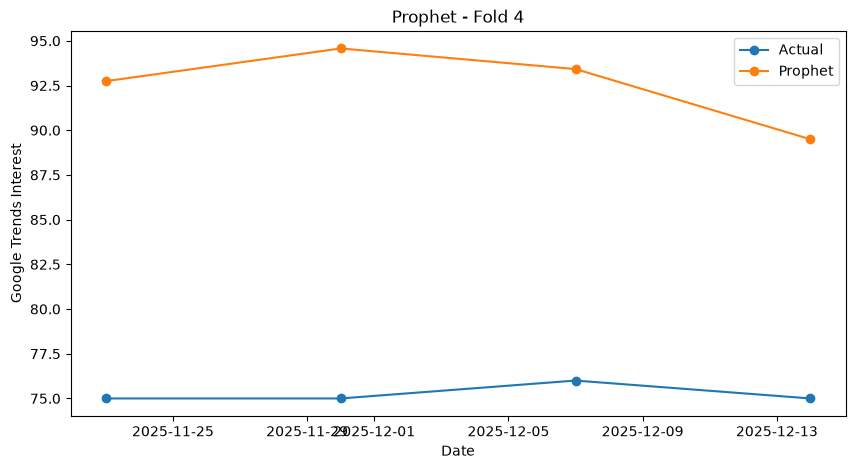

In [62]:
plt.figure(figsize=(10, 5))

plt.plot(
    fold4_prophet["ds"],
    fold4_prophet["actual"],
    marker="o",
    label="Actual",
)

plt.plot(
    fold4_prophet["ds"],
    fold4_prophet["prediction"],
    marker="o",
    label="Prophet",
)

plt.title("Prophet - Fold 4")
plt.xlabel("Date")
plt.ylabel("Google Trends Interest")
plt.legend()
plt.show()

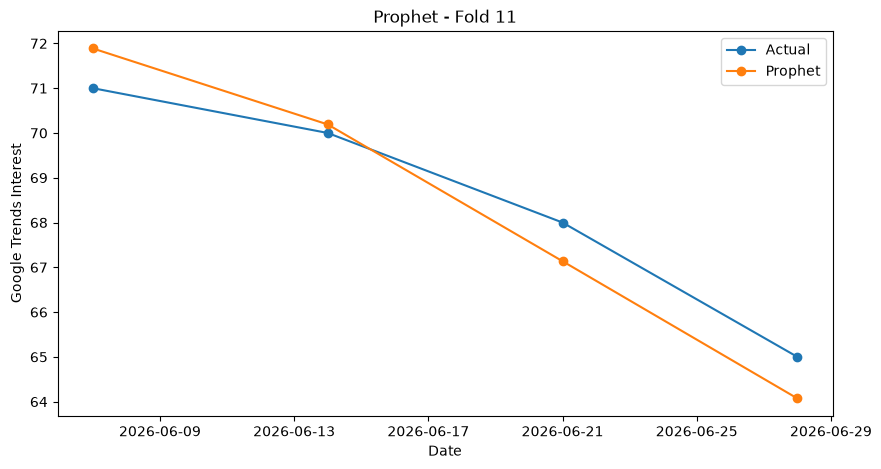

In [63]:
plt.figure(figsize=(10, 5))

plt.plot(
    fold11_prophet["ds"],
    fold11_prophet["actual"],
    marker="o",
    label="Actual",
)

plt.plot(
    fold11_prophet["ds"],
    fold11_prophet["prediction"],
    marker="o",
    label="Prophet",
)

plt.title("Prophet - Fold 11")
plt.xlabel("Date")
plt.ylabel("Google Trends Interest")
plt.legend()
plt.show()

Bu iki grafik Prophet’in neden ortalamada dengesiz çıktığını çok net gösteriyor.

Fold 4’te sorun çok büyük: gerçek değerler yaklaşık **75–76** civarında kalırken Prophet **89–95** civarında tahmin ediyor. Yani burada model yönü biraz aşağı çevirse bile **seviyeyi tamamen yanlış yerde kurmuş**. Sorun sadece “bir haftayı kaçırdı” değil; dört haftanın tamamında sistematik biçimde fazla tahmin ediyor.

Fold 11 ise tam tersi. Gerçek seri:

`71 → 70 → 68 → 65`

Prophet yaklaşık:

`71.9 → 70.2 → 67.1 → 64.1`

tahmin etmiş. Hem yönü hem düşüş hızını çok iyi yakalamış. Bu yüzden MAE `0.72` gibi çok düşük.

Bu bize Prophet hakkında şunu söylüyor:

> Prophet trendin şekli mevcut döneme uyuyorsa çok başarılı olabiliyor; fakat geçmişten öğrendiği trend/seasonality seviyesi yanlışsa bütün 4 haftayı yanlış seviyede tahmin edebiliyor.

## Yani:

Şunu demek istedim:

Prophet geleceği tahmin ederken kabaca iki şeye bakıyor:

* **Trend:** Serinin genel seviyesi ve yönü. Mesela “ChatGPT ilgisi şu sıralar 80 civarında ve yükseliyor.”
* **Seasonality:** Belirli dönemlerde tekrar eden hareketler. Mesela “Her yıl bu aylarda ilgi biraz artıyor.”

Şimdi **Fold 11**’de Prophet’in geçmişten öğrendiği davranış, gerçek test dönemine çok benzemiş:

```text
Gerçek:   71 → 70 → 68 → 65
Prophet:  72 → 70 → 67 → 64
```

Yani model doğru seviyeden başlamış ve düşüş yönünü de doğru yakalamış. Bu yüzden çok iyi tahmin etmiş.

Ama **Fold 4**’te Prophet geçmişe bakıp kabaca:

> “Bu dönemde ChatGPT ilgisi 90 civarlarında olmalı.”

gibi bir beklenti oluşturmuş.

Gerçekte ise değerler:

```text
75 → 75 → 76 → 75
```

civarında kalmış.

Prophet ise:

```text
93 → 95 → 93 → 89
```

demiş.

Yani mesele şu değil:

> “Prophet biraz yanlış tahmin etti.”

Asıl mesele:

> **Prophet geleceğin başlayacağı seviyeyi yanlış anlamış.**

Şöyle düşün:

Birine “yarın hava kaç derece olur?” diyorsun.

Kişi:

> “Bu mevsimde genelde 30 derece oluyor.”

diye düşünüp `30` civarında tahmin yapıyor.

Ama o yıl hava aslında `18` derece civarında gidiyorsa, sonraki birkaç günü de:

```text
30, 29, 28, 28
```

diye tahmin edebilir.

Yönü doğru bile olsa gerçek seviyeden çok uzaktır.

Fold 4’te Prophet’in yaşadığı şey buna benziyor.

O yüzden şimdi kontrol etmek istediğimiz şey:

> **Prophet neden “yaklaşık 90” seviyesi bekledi?**

Bunu öğrenmek için tahminin içindeki `trend` ve `yearly seasonality` parçalarına bakacağız. Yani “90’ın ne kadarı genel trendden, ne kadarı yıllık mevsimsellikten geliyor?” sorusunu cevaplayacağız.


Şimdi asıl önemli soru şu: **Fold 4’te o 93–95 tahminini Prophet’in hangi bileşeni yukarı çekiyor?**

Prophet’in tahmini kabaca şu parçalardan oluşuyor:

`yhat = trend + seasonality + diğer etkiler`

Biz `yearly_seasonality=True` yaptığımız için özellikle iki şüphelimiz var: **trend** ve **yearly seasonality**.

Bunu Fold 4 için görelim. 



Burada mesela şöyle bir şey görürsek:

```text
trend   ≈ 84
yearly  ≈ +10
yhat    ≈ 94
```

o zaman diyeceğiz ki:

> “Prophet 84 civarında bir temel trend bekliyor, üzerine yılın bu dönemine +10 seasonal etki ekliyor; bu yüzden 94 tahmin ediyor.”

Bu özellikle önemli, çünkü elimizde yaklaşık 3 yıllık veri var ve Fold 4’te model aslında bunun da tamamını görmemiş durumda. Dolayısıyla **yıllık seasonality fazla güçlü öğrenilmiş olabilir**.

Önce bu `trend` ve `yearly` tablosunu çıkar. Sonuca göre Prophet’te ilk değiştirmemiz gereken şey `yearly_seasonality` mi yoksa trend esnekliğini belirleyen `changepoint_prior_scale` mı, onu seçelim.


In [64]:

train_index, test_index = list(
    tscv_4w.split(chatgpt)
)[3]

fold4_train = chatgpt.iloc[train_index]
fold4_test = chatgpt.iloc[test_index]

fold4_train_df = (
    fold4_train
    .rename("y")
    .reset_index()
    .rename(columns={"date": "ds"})
)

fold4_test_df = (
    fold4_test
    .rename("y")
    .reset_index()
    .rename(columns={"date": "ds"})
)

fold4_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
)

fold4_model.fit(fold4_train_df)

fold4_forecast = fold4_model.predict(
    fold4_test_df[["ds"]]
)





fold4_forecast[
    [
        "ds",
        "yhat",
        "trend",
        "yearly",
    ]
]


14:42:27 - cmdstanpy - INFO - Chain [1] start processing
14:42:27 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat,trend,yearly
0,2025-11-23,92.742611,89.186924,3.555688
1,2025-11-30,94.573134,90.108702,4.464432
2,2025-12-07,93.419142,91.030479,2.388662
3,2025-12-14,89.494395,91.952257,-2.457862


# 📌 4. Fold İçi Prophet Kodu  Analizi ve Bileşen İncelemesi

* **🎯 Amaç:** Çapraz doğrulama (Cross-Validation) sürecindeki **4. Fold'u (son sınav dilimini)** özel olarak dışarı çıkararak, sadece bu zaman dilimi üzerinde Prophet modelini eğitmek; test dönemine denk gelen tarihler için tahmin üretip modelin bu tahmini yaparken kullandığı **ana bileşenleri (trend, yıllık mevsimsellik vb.) ayrı ayrı** incelemektir.
* **🛠️ Gerekli Fonksiyonlar & Yapılar:** `list()`, Indeksleme (`[3]`), `.iloc[]`, `.rename()`, `.reset_index()`, `Prophet()`, `.fit()`, `.predict()`, Sütun Filtreleme (`[["ds", ...]]`)

---

### ⚙️ İşlevleri & Mantığı

1. **`list(tscv_4w.split(chatgpt))[3]` (4. Fold'un İndekslerini Yakalama):**
* **`tscv_4w.split(chatgpt)`:** Tüm zaman serisini genişleyen pencere yöntemiyle parçalara bölen bir üreteçtir (generator).
* **`list(...)`:** Üreteç yapısını bellek üzerinde indexlenebilir standart bir Python listesine dönüştürür.
* **`[3]`:** Listeler 0 tabanlı indekslendiği için (0: 1. Fold, 1: 2. Fold, 2: 3. Fold, **3: 4. Fold**), doğrudan **son ve en geniş eğitim verisine sahip olan 4. Fold'un** `(train_index, test_index)` çiftini çeker.


2. **Veri Dilimleme ve Prophet Formatına Dönüştürme:**
* **`fold4_train` / `fold4_test`:** `.iloc[]` kullanılarak ana seriden 4. Fold'a ait eğitim ve test parçaları kesilir.
* **`fold4_train_df` / `fold4_test_df`:** Kesilen bu iki parça, Prophet'in zorunlu beklediği `ds` (tarih) ve `y` (hedef değer) kolon isimlerine ve yapısına getirilir.


3. **4. Fold Modelinin Kurulması ve Eğitilmesi (`fold4_model`):**
* Sadece 4. Fold'un kapsamındaki genişleyen geçmiş veriyi (`fold4_train_df`) kullanarak bağımsız bir Prophet modeli eğitilir.


4. **Tahmin Üretme (`fold4_model.predict(...)`):**
* Model, 4. Fold'un test tarihlerine denk gelen günleri (`fold4_test_df[["ds"]]`) alarak hem nihai tahmini (`yhat`) hem de o tarihlere denk gelen alt bileşen değerlerini (trend, yearly vb.) hesaplar.


5. **Bileşen Detaylı Filtreleme:**
* Prophet'in ürettiği zengin tahmin tablosundan sadece zaman serisi decomposition (ayrıştırma) mantığını anlamamızı sağlayan kilit kolonlar süzülür.



---

### 📥 İstenen Parametreler & Anlamları

* **Indeksleme İşlemleri için:**
* **`[3]` (int)**: `TimeSeriesSplit` nesnesi 4 bölmeye ayıracak şekilde tanımlandığından (`n_splits=4`), en sonuncu parçayı temsil eden 3. indeks seçilmiştir.


* **`Prophet()` sınıfı için:**
* **`yearly_seasonality=True`**: Yıl içindeki tekrarlayan hareketleri hesaplaması söylenir.
* **`weekly_seasonality=False` / `daily_seasonality=False**`: Verimiz haftalık olduğu için gün içi ve saatlik mevsimsellik hesaplamaları devre dışı bırakılmıştır.


* **`.predict()` metodu için:**
* **`df` (pandas DataFrame)**: Yalnızca test tarih kümesini içeren `fold4_test_df[["ds"]]` verilmiştir.



---

### 💡 Derinlemesine Detay: Ekran Çıktısındaki Sütunlar Ne Anlama Geliyor?

Bu kodun en sonunda seçilen 4 sütun, Prophet'in tahmin motorunun iç organlarını bize gösterir:

| Sütun Adı | Anlamı ve Matematiksel Karşılığı |
| --- | --- |
| **`ds`** | Tahmin yapılan **test tarihi**. |
| **`yhat`** | Modelin o tarih için ürettiği **nihai tahmin değeri** ($\hat{y}$). |
| **`trend`** | O tarihteki **uzun vadeli ana eğilim/gidişat** seviyesi (Mevsimsellikten arındırılmış saf çizgi). |
| **`yearly`** | O tarihte yıllık mevsimselliğin trende yaptığı **artı veya eksi etki** (Mevsimsellik puanı). |

> **Toplamsal (Additive) Denklem Mantığı:**
> Prophet arka planda şu temel toplama işlemini yapar:
> 
> $$\text{yhat} = \text{trend} + \text{yearly}$$
> 
> 
> Çıktıda göreceğin `yhat` sayısı, tam olarak `trend` sütunundaki değer ile `yearly` sütunundaki değerin (varsa diğer bileşenlerle birlikte) toplanmasıyla elde edilen sonuçtur.

In [65]:
fold4_train.tail(15)

date
2025-08-10    72
2025-08-17    75
2025-08-24    79
2025-08-31    79
2025-09-07    85
2025-09-14    91
2025-09-21    79
2025-09-28    82
2025-10-05    85
2025-10-12    85
2025-10-19    83
2025-10-26    82
2025-11-02    85
2025-11-09    86
2025-11-16    84
Name: chatgpt, dtype: int64

Evet, şimdi Prophet’in neden Fold 4’te 90’lara çıktığı daha anlaşılır.

Train’in son kısmı kabaca şöyle:

72 → 75 → 79 → 79 → 85 → 91
                       ↓
79 → 82 → 85 → 85 → 83 → 82 → 85 → 86 → 84

Yani Prophet’in gördüğü geçmişte genel olarak 72’lerden 80’lerin ortasına doğru belirgin bir yükseliş var. Son birkaç haftada 82–86 civarında yataylaşma başlasa bile Prophet uzun dönemli yükseliş eğilimini biraz fazla güçlü devam ettirmiş ve:

89 → 90 → 91 → 92

şeklinde trend üretmiş.

Gerçekte ise test başladığında:

75 → 75 → 76 → 75

olmuş. Yani tam o noktada geçmişteki yüksek seviyeden aşağı doğru bir seviye değişimi gerçekleşmiş. Prophet bunu önceden bilememiş.

Şimdi Prophet’in önemli bir ayarını test edeceğiz:

changepoint_prior_scale

Bu ayar kabaca:

“Prophet trendin yönünün/hızının değişmesine ne kadar izin versin?”

demek.

Küçük değer → trend daha katı ve düzgün olur.
Büyük değer → trend değişikliklerine daha esnek davranır.

Prophet’in varsayılan değeri yaklaşık:

0.05

Biz birkaç değer deneyebiliriz:

changepoint_values = [
    0.01,
    0.05,
    0.1,
    0.2,
    0.5,
]

Ama tek Fold 4’e göre seçim yapmayacağız. Her ayarı yine 12 fold × 4 hafta cross-validation’da sınayacağız.

# Prophet'in Çalışma Mantığı (Örneklerle)

Tabii. Prophet’i en basit haliyle bir **“çizginin gidişatını + tekrar eden dönemsel hareketleri öğrenip ileri uzatan model”** gibi düşün.

Mesela elimizde şöyle bir satış serisi olsun:

```text
Hafta 1 → 10
Hafta 2 → 12
Hafta 3 → 14
Hafta 4 → 16
Hafta 5 → 18
```

Prophet burada önce şunu fark eder:

> “Genel olarak değer her hafta yükseliyor.”

Bu kısma **trend** diyoruz.

Kabaca trend:

```text
10 → 12 → 14 → 16 → 18 → 20 → 22 ...
```

gibi ileri uzatılabilir.

Şimdi biraz daha gerçekçi olsun:

```text
Hafta 1 → 10
Hafta 2 → 14
Hafta 3 → 13
Hafta 4 → 17
Hafta 5 → 16
```

Burada değerler dümdüz yükselmiyor ama genel yön hâlâ yukarı. Prophet küçük iniş çıkışların arkasındaki ana yolu bulmaya çalışıyor:

```text
Gerçek:
10 ── 14 ── 13 ── 17 ── 16

Trend:
10 ── 12 ── 14 ── 16 ── 18
```

Prophet’in ilk önemli işi bu.

Şimdi **seasonality** ekleyelim. Diyelim bir dondurma dükkânının aylık satışları var:

```text
Ocak   → düşük
Şubat  → düşük
...
Temmuz → çok yüksek
Ağustos→ çok yüksek
...
Aralık → düşük
```

Bu davranış her yıl tekrar ediyorsa Prophet şöyle öğrenebilir:

> “Temmuz geldiğinde normal trendin üstüne biraz eklemeliyim.”

Mesela genel trend o Temmuz için `100` diyorsa:

```text
trend = 100
yaz mevsimi etkisi = +20
```

Prophet’in tahmini yaklaşık:

```text
120
```

olabilir.

Bizim kodda gördüğümüz:

```text
trend
yearly
yhat
```

tam olarak bununla ilgili.

Senin Fold 4 ilk haftan:

```text
trend  = 89.19
yearly = +3.56
yhat   = 92.74
```

Yani Prophet:

> “Geçmiş veriye bakınca bu tarihte ana seviye yaklaşık 89 olmalı. Ayrıca yılın bu döneminin yaklaşık +3.6 etkisi var. O halde tahminim yaklaşık 92.7.”

diyor.

Ama gerçek:

```text
75
```

oldu.

Yani problem özellikle Prophet’in **trend kısmında**.

Bir de Prophet’in önemli özelliği **changepoint**.

Mesela veri:

```text
10
12
14
16
18
20
22
24
```

diye giderken bir noktadan sonra:

```text
24
24
23
24
23
```

olmaya başlasın.

Burada artık eski büyüme hızı devam etmiyor.

Prophet:

> “Burada trendin davranışı değişmiş olabilir.”

diyebilir.

Bu değişimin olduğu noktalara **changepoint** deniyor.

Senin ChatGPT serisinde de buna benzeyen durumlar var:

```text
72 → 75 → 79 → 85 → 91
```

güçlü yükseliş var.

Sonra:

```text
79 → 82 → 85 → 83 → 82 → 85 → 86 → 84
```

gibi daha yatay bir yapı oluşuyor.

Prophet’in görevi bu değişimleri fark edip geleceğe uygun trend çizmek. Fakat bizim Fold 4’te modeli eğittiğimiz anda Prophet yükseliş eğilimini **fazla güçlü devam ettirmiş**:

```text
89 → 90 → 91 → 92
```

Gerçekte ise test dönemi:

```text
75 → 75 → 76 → 75
```

olmuş.

Bu noktada çok önemli bir şey var: Prophet **gelecekte 75’e düşüleceğini bilemez**. Ona sadece geçmişi gösteriyoruz. Eğer bu düşüş dışarıdan gelen beklenmedik bir olay nedeniyle olduysa, sadece geçmiş Google Trends değerlerine bakarak bunu tahmin etmek zaten çok zor.

Prophet’in çalışma mantığını tek cümlede toplarsak:

> **Geçmiş veriden genel trendi öğrenir, trenddeki değişim noktalarını bulmaya çalışır, tekrar eden mevsimsel etkileri ekler ve bunları geleceğe uzatarak `yhat` tahminini oluşturur.**

Bizde çok basitleştirirsek:

```text
                 GEÇMİŞ VERİ
                     ↓
          ┌──────────┴──────────┐
          ↓                     ↓
       TREND               SEASONALITY
   genel gidişat          dönemsel etki
          ↓                     ↓
          └──────────┬──────────┘
                     ↓
                   YHAT
                  tahmin
```

ARIMA ile temel farkı da şu: **ARIMA daha çok “son değerler ve geçmiş hatalar birbirleriyle nasıl ilişkili?” diye bakıyordu. Prophet ise “serinin genel trendi ne, trend nerelerde değişiyor ve dönemsel tekrar var mı?” diye bakıyor.**

Bu yüzden ikisini de deniyoruz; aynı veriye farklı gözlüklerle bakıyorlar.

Şu an Prophet için baktığımız **4 haftalık cross-validation’daki Fold 4** şöyleydi:

```text
TRAIN
2023-07-30
      ↓
2025-11-16

TEST
2025-11-23
2025-11-30
2025-12-07
2025-12-14
```

Yani Prophet, **30 Temmuz 2023–16 Kasım 2025 arasındaki bütün veriyi** görüp öğrendi. Sonra 23 Kasım–14 Aralık 2025 arasındaki 4 haftayı hiç görmeden tahmin etti.

O testte gerçekler:

```text
75 → 75 → 76 → 75
```

Prophet ise yaklaşık:

```text
92.7 → 94.6 → 93.4 → 89.5
```

tahmin etti. O yüzden Fold 4 çok kötü çıktı.

Karışmasın diye önemli: Daha önceki **12 haftalık cross-validation’daki Fold 4** farklıydı (`2026-05-10 → 2026-07-26`). Şu anda konuştuğumuz, **12 fold × 4 hafta sistemindeki Fold 4**.

### o zaman şöyle olamaz mı 23 kasım itibari ondan önce olmayan bir stabillik gerçekleşti?

Evet, **tam olarak böyle bir ihtimal var**. Hatta Fold 4’te gördüğümüz şey için en mantıklı açıklamalardan biri bu.

16 Kasım’a kadar Prophet’in gördüğü son dönem kabaca:

```text
79 → 85 → 91 → 79 → 82 → 85 → 85 → 83 → 82 → 85 → 86 → 84
```

Yani seri yüksek seviyede ve hâlâ oldukça hareketli.

Sonra test başlıyor:

```text
23 Kasım → 75
30 Kasım → 75
7 Aralık → 76
14 Aralık → 75
```

Burada gerçekten **önceki döneme göre yeni ve daha düşük bir seviyede kısa süreli bir stabilizasyon** oluşmuş gibi görünüyor.

Buna zaman serilerinde kabaca **regime change / structural break** diyebiliriz:

> Serinin daha önceki davranış biçiminin değişip yeni bir davranış biçimine geçmesi.

Örneğin:

```text
Önce:
yüksek seviye + fazla hareket
80–90 civarı

        ↓ yapısal değişim

Sonra:
daha düşük ve daha stabil
75–76 civarı
```

Ve Prophet’in Fold 4’te neden bu kadar kötü kaldığını bu çok iyi açıklıyor. Çünkü Prophet’in train verisi **16 Kasım’da bitiyor**. Yani 23 Kasım’da başlayacak bu yeni davranışı daha önce hiç görmemiş.

Prophet:

> “Ben şimdiye kadar gördüğüm yükselen/yüksek trendi geleceğe uzatayım.”

deyip yaklaşık `90` tahmin ediyor.

Ama gerçek dünyada tam test başladığı anda seri yeni bir seviyeye geçiyor:

```text
Prophet'in bildiği dünya:
84 → geçmiş trend devam eder → 89, 90, 91...

Gerçekte olan:
84 → 75 → 75 → 76 → 75
          ↑
      yeni davranış
```

Burada çok önemli bir nokta var: **`changepoint_prior_scale` ayarını büyütmek bile gelecekte henüz gerçekleşmemiş bir kırılmayı sihirli şekilde bilemez.** Prophet changepoint’leri esas olarak geçmişte gördüğü veriden öğreniyor.

O yüzden Fold 4’teki kötü sonuç doğrudan “Prophet kötü model” anlamına gelmeyebilir. Daha doğru ifade:

> **Test döneminin başlangıcında daha önce train verisinde görülmeyen bir seviye/trend değişimi gerçekleşmiş olabilir ve Prophet bu yeni rejimi önceden tahmin edememiştir.**

Ama “23 Kasım’dan sonra kalıcı stabilite başladı” demek için biraz dikkatli olmalıyız. Çünkü birkaç hafta sonra elimizde:

```text
21 Aralık → 57
28 Aralık → 54
```

gibi sert düşüşler de vardı. Yani **23 Kasım–14 Aralık arasında kısa bir stabilizasyon** var; sonrasında seri tekrar ciddi değişiyor.

Bu aslında projemiz açısından çok değerli bir bulgu: ChatGPT Trends serisi tek bir sabit davranış göstermiyor; **rejim değişimleri ve ani dış etkiler var.** Bu da neden ARIMA ve Prophet’in bazı foldlarda çok iyi, bazılarında çok kötü olduğunu açıklamaya başlıyor.






In [66]:
def evaluate_prophet_cv(
    series,
    splitter,
    changepoint_prior_scale=0.05,
):
    results = []

    for fold, (train_index, test_index) in enumerate(
        splitter.split(series),
        start=1,
    ):
        fold_train = series.iloc[train_index]
        fold_test = series.iloc[test_index]

        train_df = (
            fold_train
            .rename("y")
            .reset_index()
            .rename(columns={"date": "ds"})
        )

        test_df = (
            fold_test
            .rename("y")
            .reset_index()
            .rename(columns={"date": "ds"})
        )

        model = Prophet(
            yearly_seasonality=True,
            weekly_seasonality=False,
            daily_seasonality=False,
            changepoint_prior_scale=changepoint_prior_scale,
        )

        model.fit(train_df)

        forecast = model.predict(
            test_df[["ds"]]
        )

        mae = mean_absolute_error(
            test_df["y"],
            forecast["yhat"],
        )

        rmse = root_mean_squared_error(
            test_df["y"],
            forecast["yhat"],
        )

        results.append(
            {
                "fold": fold,
                "MAE": mae,
                "RMSE": rmse,
            }
        )

    return pd.DataFrame(results)

In [69]:
changepoint_values = [
    0.01,
    0.05,
    0.1,
    0.2,
    0.5,
    1.0,
    1.25,
    1.5,
    2.0,
]

prophet_tuning_results = []

for value in changepoint_values:
    result = evaluate_prophet_cv(
        chatgpt,
        tscv_4w,
        changepoint_prior_scale=value,
    )

    prophet_tuning_results.append(
        {
            "changepoint_prior_scale": value,
            "MAE": result["MAE"].mean(),
            "RMSE": result["RMSE"].mean(),
        }
    )

prophet_tuning_df = pd.DataFrame(
    prophet_tuning_results
)

prophet_tuning_df.sort_values("MAE")

15:16:33 - cmdstanpy - INFO - Chain [1] start processing
15:16:33 - cmdstanpy - INFO - Chain [1] done processing
15:16:33 - cmdstanpy - INFO - Chain [1] start processing
15:16:33 - cmdstanpy - INFO - Chain [1] done processing
15:16:33 - cmdstanpy - INFO - Chain [1] start processing
15:16:33 - cmdstanpy - INFO - Chain [1] done processing
15:16:33 - cmdstanpy - INFO - Chain [1] start processing
15:16:33 - cmdstanpy - INFO - Chain [1] done processing
15:16:33 - cmdstanpy - INFO - Chain [1] start processing
15:16:33 - cmdstanpy - INFO - Chain [1] done processing
15:16:33 - cmdstanpy - INFO - Chain [1] start processing
15:16:33 - cmdstanpy - INFO - Chain [1] done processing
15:16:33 - cmdstanpy - INFO - Chain [1] start processing
15:16:33 - cmdstanpy - INFO - Chain [1] done processing
15:16:33 - cmdstanpy - INFO - Chain [1] start processing
15:16:33 - cmdstanpy - INFO - Chain [1] done processing
15:16:33 - cmdstanpy - INFO - Chain [1] start processing
15:16:33 - cmdstanpy - INFO - Chain [1]

,changepoint_prior_scale,MAE,RMSE
6,1.25,4.297496,4.828445
5,1.00,4.303037,4.825669
8,2.00,4.320227,4.891001
7,1.50,4.330898,4.866450
4,0.50,4.564362,5.161293
3,0.20,5.272655,5.869681
2,0.10,5.915125,6.439323
1,0.05,6.829498,7.409934
0,0.01,12.456074,12.966422


# Overfit Nedir?

Prophet geçmiş veriye bakıp trend çiziyor. `changepoint_prior_scale` yani `cps` büyüdükçe Prophet’e şunu demiş oluyoruz:

> “Trend sık sık değişebilir, buna daha çok izin ver.”

Mesela gerçek geçmiş veri şöyle olsun:

```text
10, 12, 11, 13, 12, 14, 13, 15
```

Burada genel yön yukarı ama küçük zikzaklar da var.

Düşük `cps` ile Prophet şöyle düşünür:

```text
10 → 11 → 12 → 13 → 14 → 15
```

Yani küçük oynaklıkları önemsemez, daha düz bir trend öğrenir.

CPS çok büyürse model şunu yapmaya başlayabilir:

```text
10 → 12 ↓ 11 ↑ 13 ↓ 12 ↑ 14 ↓ 13 ↑ 15
```

Yani geçmişteki **her küçük iniş çıkışı önemli bir trend değişimi sanabilir**.

İşte buna basitçe **overfitting** diyoruz:

> Model geçmiş veriyi gereğinden fazla ezberliyor.

Geçmişi çok güzel açıklıyor ama yeni, görmediği gelecekte kötü tahmin yapabiliyor.

Okul örneğiyle düşün: Bir öğrenci soruların mantığını öğrenmek yerine deneme sınavındaki soruları ezberliyor. Aynı sorular gelirse çok iyi, ama biraz farklı soru gelirse zorlanıyor. Bu da overfit’e benziyor.

Bizde şu an:

```text
cps 0.05 → MAE 6.83
cps 0.50 → MAE 4.56
cps 1.00 → MAE 4.30
```

olduğu için `1.0`a kadar esnekliğin artması **iyi olmuş**. Ama bu:

> “10 yaparsak daha da iyi olur.”

demek değil.

Belki:

```text
cps 0.5  → 4.56
cps 1.0  → 4.30
cps 1.5  → 4.25
cps 2.0  → 4.40
cps 5.0  → 5.10
```

gibi bir noktadan sonra yeniden kötüleşebilir.

Biz bu yüzden farklı `cps` değerlerini deneyip **hata nerede en düşük oluyor** diye bakıyoruz. Yani overfit burada sadece “fazla esnek model geçmişteki gereksiz küçük hareketleri de öğrenebilir” demek.


# Analiz

Bu sonuç tam olarak az önce konuştuğumuz şeyi gösteriyor: **CPS’yi artırmak bir noktaya kadar fayda sağlıyor ama sonsuza kadar iyileştirmiyor.**

Şu bölgeye bak:

|  CPS |        MAE |       RMSE |
| ---: | ---------: | ---------: |
| 1.00 |     4.3030 | **4.8257** |
| 1.25 | **4.2975** |     4.8284 |
| 1.50 |     4.3309 |     4.8665 |
| 2.00 |     4.3202 |     4.8910 |

`1.25` MAE açısından en iyi; ama `1.00` RMSE açısından en iyi. Üstelik aralarındaki fark inanılmaz küçük:

```text
MAE farkı:
4.3030 - 4.2975 ≈ 0.0055

RMSE farkı:
4.8284 - 4.8257 ≈ 0.0028
```

Yani pratik olarak **CPS 1.0 ve 1.25 neredeyse berabere**.

Sonra `1.5` ve `2.0` yaptığımızda hata tekrar yükselmeye başlıyor. İşte burada “daha esnek yapmaya devam etmek her zaman daha iyi değil” dediğimiz şeyi görüyoruz.

Ben bu projede **`changepoint_prior_scale=1.0` seçerdim**. Çünkü MAE’si 1.25’ten sadece 0.005 kötü ama RMSE’si biraz daha iyi ve daha yuvarlak/sade bir parametre. `1.25` seçmek için güçlü bir performans farkımız yok.

Şu an karşılaştırmamız da:

```text
Prophet (cps=1.0)   MAE 4.30   RMSE 4.83
ARIMA(1,1,1)        MAE 4.41   RMSE 5.00
Naive               MAE 4.54   RMSE 5.24
```

Yani **12 fold × 4 haftalık CV’de şu an en iyi aday Prophet (`cps=1.0`)**.

Ama artık CPS’yi `1.05, 1.10, 1.15, 1.20...` diye milim milim aramayalım. Aynı cross-validation üzerinde fazla ince ayar yaparsak bu kez değerlendirme dönemlerimize aşırı özel bir parametre seçmeye başlayabiliriz. `1.0` yeterince güçlü ve mantıklı bir seçim.

Sıradaki adımda `src/forecasting.py`ye Prophet’i de düzgünce ekleyip **Naive + ARIMA + Prophet** yapısını tamamlayabiliriz.


### Şimdi Prophet’i de src/forecasting.py içine ekleyip modülü şu hale getireceğiz:

forecasting.py
├── evaluate_naive_cv()
├── evaluate_arima_cv()
├── forecast_arima()
├── evaluate_prophet_cv()
└── forecast_prophet()

In [71]:
import importlib
import src.forecasting

importlib.reload(src.forecasting)

<module 'src.forecasting' from '/Users/nihalapple/Desktop/trend-forecast-project/notebooks/../src/forecasting.py'>

In [72]:
from src.forecasting import (
    evaluate_arima_cv,
    evaluate_naive_cv,
    evaluate_prophet_cv,
    forecast_prophet,
)


In [73]:
prophet_cv_from_src = evaluate_prophet_cv(
    chatgpt,
    tscv_4w,
    changepoint_prior_scale=1.0,
)

prophet_cv_from_src[["MAE", "RMSE"]].mean()

15:28:15 - cmdstanpy - INFO - Chain [1] start processing
15:28:15 - cmdstanpy - INFO - Chain [1] done processing
15:28:15 - cmdstanpy - INFO - Chain [1] start processing
15:28:15 - cmdstanpy - INFO - Chain [1] done processing
15:28:15 - cmdstanpy - INFO - Chain [1] start processing
15:28:15 - cmdstanpy - INFO - Chain [1] done processing
15:28:15 - cmdstanpy - INFO - Chain [1] start processing
15:28:15 - cmdstanpy - INFO - Chain [1] done processing
15:28:15 - cmdstanpy - INFO - Chain [1] start processing
15:28:15 - cmdstanpy - INFO - Chain [1] done processing
15:28:15 - cmdstanpy - INFO - Chain [1] start processing
15:28:15 - cmdstanpy - INFO - Chain [1] done processing
15:28:15 - cmdstanpy - INFO - Chain [1] start processing
15:28:15 - cmdstanpy - INFO - Chain [1] done processing
15:28:16 - cmdstanpy - INFO - Chain [1] start processing
15:28:16 - cmdstanpy - INFO - Chain [1] done processing
15:28:16 - cmdstanpy - INFO - Chain [1] start processing
15:28:16 - cmdstanpy - INFO - Chain [1]

MAE     4.303037
RMSE    4.825669
dtype: float64

sr'ye eklediğimiz fonksiyonun doğru çalıştığını onayladık.

### Son Model Karşılaştırma Tablosu:

In [74]:
naive_final = evaluate_naive_cv(
    chatgpt,
    tscv_4w,
)

arima_final = evaluate_arima_cv(
    chatgpt,
    tscv_4w,
    (1, 1, 1),
)

prophet_final = evaluate_prophet_cv(
    chatgpt,
    tscv_4w,
    changepoint_prior_scale=1.0,
)

/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init

In [75]:
final_model_comparison = pd.DataFrame(
    {
        "model": [
            "Prophet (cps=1.0)",
            "ARIMA(1,1,1)",
            "Naive",
        ],
        "MAE": [
            prophet_final["MAE"].mean(),
            arima_final["MAE"].mean(),
            naive_final["MAE"].mean(),
        ],
        "RMSE": [
            prophet_final["RMSE"].mean(),
            arima_final["RMSE"].mean(),
            naive_final["RMSE"].mean(),
        ],
    }
)

final_model_comparison = (
    final_model_comparison
    .sort_values("MAE")
    .reset_index(drop=True)
)

final_model_comparison

,model,MAE,RMSE
0,Prophet (cps=1.0),4.303037,4.825669
1,"ARIMA(1,1,1)",4.408749,4.997832
2,Naive,4.541667,5.241398


### Şimdi src içindeki Prophet fonksiyonuyla tüm elimizdeki ChatGPT verisini kullanıp 4 haftalık tahmin üretelim:

In [76]:
prophet_future = forecast_prophet(
    chatgpt,
    steps=4,
    changepoint_prior_scale=1.0,
)

prophet_future

15:31:43 - cmdstanpy - INFO - Chain [1] start processing
15:31:43 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat,yhat_lower,yhat_upper
157,2026-08-02,66.628359,62.855696,70.401437
158,2026-08-09,66.554096,62.519631,70.298791
159,2026-08-16,67.394821,63.509477,71.423139
160,2026-08-23,68.953368,64.928613,73.085338


###  Bundan sonraki adımları 2 Ağustos haftası tamamlanınca yap ve prophet doğru tahmin etmiş mi bak!!
doğru u tahmin etmiş geleceği diye şu an veri setimizde olmayan ama google trendse gelmiş olma durumu olan verileri çekelim(güncelleyelim yani).

In [77]:
from src.fetch_data import fetch_trends_data

updated_raw = fetch_trends_data(
    keywords=["chatgpt", "gemini", "claude"],
    geo="",
    timeframe="2023-07-30 2026-08-07",
)

updated_raw.tail()

429 hatası alındı. 30 saniye sonra tekrar denenecek.
429 hatası alındı. 60 saniye sonra tekrar denenecek.


,chatgpt,gemini,claude,isPartial
date,,,,
2026-07-05,67,42,17,False
2026-07-12,65,39,15,False
2026-07-19,68,39,16,False
2026-07-26,66,38,15,False
2026-08-02,68,39,16,True


In [78]:
# Sonra incomplete satırı temizle:

updated_clean = (
    updated_raw[~updated_raw["isPartial"]]
    .drop(columns=["isPartial"])
    .copy()
)

updated_clean.tail()

,chatgpt,gemini,claude
date,,,
2026-06-28,64,40,18
2026-07-05,67,42,17
2026-07-12,65,39,15
2026-07-19,68,39,16
2026-07-26,66,38,15


In [79]:
actual_aug_2 = updated_clean.loc[
    "2026-08-02",
    "chatgpt",
]

actual_aug_2

KeyError: '2026-08-02'

In [ ]:
prophet_future_with_actual = prophet_future.copy()

prophet_future_with_actual["actual"] = (
    prophet_future_with_actual["ds"]
    .map(updated_clean["chatgpt"])
)

prophet_future_with_actual[
    [
        "ds",
        "actual",
        "yhat",
        "yhat_lower",
        "yhat_upper",
    ]
]